# Session behavior + funcimg trial summary

This notebook audits every `ses-*` folder for `behav` and `funcimg` subfolders, then summarizes sessions treated as imaging sessions. Sessions with both `behav` and `funcimg` are included, and `behav`-only sessions on or after `DUMMY_SCOPE_START_DATE` are included as dummy-scope imaging sessions. Trial counts include `num_t_found` entries, which are usually dropped from downstream trial extraction.

In [127]:
from pathlib import Path
from copy import deepcopy
import json
import re
import sys
import tempfile

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "scripts":
    PROJECT_ROOT = PROJECT_ROOT.parent
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

for path in (PROJECT_ROOT, SCRIPTS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from src.behavior_import.import_data import import_data
from src.behavior_import.extract_trials import extract_trials_grouped_by_problem
from src.behavior_analysis.get_good_reversal_info import get_good_reversal_info
from src.behavior_analysis.get_rank_counts_by_good_reversal import get_rank_counts_by_good_reversal
from src.behavior_analysis.get_diagnostic_p_value import pvalue_paired_t_best_vs_second_vs_third
from src.behavior_analysis.get_variables_across_sessions import get_vars_across_all_sessions
from src.behavior_analysis.get_believed_value import compute_believed_value
import src.behavior_visualization.plot_style  # noqa: F401  # applies shared matplotlib rcParams
from src.behavior_visualization.plot_rank_proportions import plot_rank_proportions
from src.behavior_visualization.plot_single_session import plot_single_session
from src.behavior_visualization.plot_style import MOUSE_COLORS
from scripts.fix_grid_maze_cohort_02_problems import fix_grid_maze_cohort_02_problems

# Analysis label and SMB experiment folder. Edit these three values as needed.
task = "open-field"
cohort = "cohort-01"
folder_name = "3x3_field_magnitude_bandit"

# For grid maze, use:
# task = "grid-maze"
# cohort = "cohort-02"
# folder_name = "3x3_maze_blocked_reward_bandit"

root = f"/Volumes/behrens/meg/{folder_name}/rawdata/{cohort}/"
DATA_ROOT = Path(root)
MIN_SESSION_DATE = pd.Timestamp("2026-07-30")
DUMMY_SCOPE_START_DATE = pd.Timestamp("2026-07-01")
DUMMY_SCOPE_COLOR = "#DD8452"

# Restrict the notebook to these mouse IDs. Use None or [] to include all subjects.
SUBJECT_IDS_TO_INCLUDE = ["MY_71_R"]

# Optional exclusions after mouse-relative imaging signatures are assigned.
EXCLUDED_RELATIVE_IMAGING_PROBLEMS = []

SESSION_RE = re.compile(r"ses-(?P<session_number>\d+)_date-(?P<date>\d{8})$")
SUBJECT_RE = re.compile(r"sub-(?P<subject_number>\d+)_id-(?P<subject_id>.+)$")
TRIAL_KEYS = {
    "num_trials",
    "num_t",
    "trial",
    "num_t_found",
}
REGULAR_TRIAL_KEYS = TRIAL_KEYS - {"num_t_found"}
CHOICE_TOWER_KEYS = (
    "current_choice_towers",
    "curr_choice_tows",
    "choice_towers",
    "c_tows",
)
INITIATION_TOWER_KEYS = (
    "current_initiation_tower",
    "curr_initiation_tow",
    "initiation_tower",
)

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 120)

DATA_ROOT

PosixPath('/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01')

## Resolve and check the rawdata root

In [128]:
def count_files_fast(root_path, pattern, stop_after=1):
    root_path = Path(root_path)
    if not root_path.exists():
        return 0
    count = 0
    for _ in root_path.rglob(pattern):
        count += 1
        if count >= stop_after:
            return count
    return count


def find_candidate_rawdata_roots(folder_name, cohort):
    base = Path("/Volumes/behrens/meg") / folder_name / "rawdata" / cohort
    candidates = []
    return [p for p in candidates if p.exists()]


print(f"Requested root: {DATA_ROOT}")
print(f"Root exists: {DATA_ROOT.exists()}")
print(f"Contains TSV files: {bool(count_files_fast(DATA_ROOT, '*.tsv'))}")
print(f"Contains session folders: {bool(count_files_fast(DATA_ROOT, 'ses-*_date-*'))}")

candidate_roots = find_candidate_rawdata_roots(folder_name, cohort)
candidate_summary = pd.DataFrame([
    {
        "candidate_root": p,
        "has_tsv": bool(count_files_fast(p, "*.tsv")),
        "has_sessions": bool(count_files_fast(p, "ses-*_date-*")),
    }
    for p in candidate_roots
])

if not candidate_summary.empty:
    display(candidate_summary)

if not DATA_ROOT.exists() or not count_files_fast(DATA_ROOT, "*.tsv"):
    usable = candidate_summary[candidate_summary["has_tsv"]] if not candidate_summary.empty else pd.DataFrame()
    if not usable.empty:
        DATA_ROOT = Path(usable.iloc[0]["candidate_root"])
        root = str(DATA_ROOT)
        print(f"Using detected rawdata root instead: {DATA_ROOT}")
    else:
        print("No TSV-containing rawdata root detected. Check folder_name, cohort, problem_name, and that the SMB volume is mounted.")

DATA_ROOT

Requested root: /Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01
Root exists: True
Contains TSV files: True
Contains session folders: True


PosixPath('/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01')

## Load behavior data with project helpers

In [129]:
# This follows the standard project workflow, but first builds a temporary
# rawdata view containing only sessions on or after MIN_SESSION_DATE. That keeps
# old sessions out of both import_data and extract_trials_grouped_by_problem.
def build_min_date_rawdata_view(source_root, min_session_date, subject_ids_to_include=None):
    source_root = Path(source_root)
    min_session_date = pd.Timestamp(min_session_date).normalize()
    subject_ids_to_include = set(subject_ids_to_include or [])
    temp_dir = tempfile.TemporaryDirectory(prefix="min-date-rawdata-")
    filtered_root = Path(temp_dir.name) / "rawdata"

    n_subject_dirs = 0
    n_session_dirs = 0
    n_tsv_files = 0

    for subject_dir in sorted(source_root.glob("sub-*")):
        subject_match = SUBJECT_RE.match(subject_dir.name)
        if not subject_dir.is_dir() or not subject_match:
            continue
        subject_id = subject_match.group("subject_id")
        if subject_ids_to_include and subject_id not in subject_ids_to_include:
            continue

        subject_had_included_sessions = False
        for session_dir in sorted(subject_dir.glob("ses-*_date-*")):
            if not session_dir.is_dir():
                continue

            match = SESSION_RE.match(session_dir.name)
            if not match:
                continue

            session_date = pd.to_datetime(match.group("date"), format="%Y%m%d").normalize()
            if session_date < min_session_date:
                continue

            session_tsv_count = 0
            for tsv_path in sorted(session_dir.rglob("*.tsv")):
                # Skip macOS AppleDouble sidecar files; they are not real TSV data.
                if tsv_path.name.startswith("._"):
                    continue
                dest = filtered_root / tsv_path.relative_to(source_root)
                dest.parent.mkdir(parents=True, exist_ok=True)
                if not dest.exists():
                    dest.symlink_to(tsv_path)
                session_tsv_count += 1

            if session_tsv_count:
                subject_had_included_sessions = True
                n_session_dirs += 1
                n_tsv_files += session_tsv_count

        if subject_had_included_sessions:
            n_subject_dirs += 1

    info = {
        "n_subject_dirs": n_subject_dirs,
        "n_session_dirs": n_session_dirs,
        "n_tsv_files": n_tsv_files,
    }
    return temp_dir, filtered_root, info


def safe_json_load_for_import(value):
    if pd.isna(value):
        return {}
    if isinstance(value, (dict, list)):
        return value
    try:
        return json.loads(value)
    except Exception:
        return {}


def dataframe_has_regular_trial_info(df):
    if df is None or df.empty:
        return False
    if not {"type", "subtype", "content"}.issubset(df.columns):
        return False

    trials_df = df[
        df["type"].eq("variable")
        & df["subtype"].eq("print")
    ]
    if trials_df.empty:
        return False

    for value in trials_df["content"]:
        parsed = safe_json_load_for_import(value)
        if not isinstance(parsed, dict):
            continue
        # Finding-port rows are useful for raw counts, but are intentionally
        # excluded by extract_trials and should not make a file count as a trial segment.
        if "num_t_found" in parsed:
            continue
        if parsed.keys() & REGULAR_TRIAL_KEYS:
            return True
    return False


def drop_empty_behavior_file_segments(subjects):
    cleaned_sessions = 0
    dropped_segments = 0

    for subject_key, subject_sessions in subjects.items():
        for session_key, session_data in subject_sessions.items():
            data_obj = session_data.get("data")
            df_obj = session_data.get("df")
            if not isinstance(data_obj, list):
                continue

            raw_df_list = df_obj if isinstance(df_obj, list) else [df_obj] * len(data_obj)
            keep_indices = [
                i for i, df in enumerate(raw_df_list)
                if dataframe_has_regular_trial_info(df)
            ]

            if not keep_indices:
                continue
            if len(keep_indices) == len(data_obj):
                continue

            cleaned_sessions += 1
            dropped_segments += len(data_obj) - len(keep_indices)
            kept_data = [data_obj[i] for i in keep_indices]
            kept_df = [raw_df_list[i] for i in keep_indices]

            session_data["data"] = kept_data[0] if len(kept_data) == 1 else kept_data
            session_data["df"] = kept_df[0] if len(kept_df) == 1 else kept_df
            print(
                f"[INFO] Dropped {len(data_obj) - len(keep_indices)} no-trial file segment(s) "
                f"for subject {subject_key}, session {session_key}."
            )

    if cleaned_sessions:
        print(
            f"[INFO] Dropped {dropped_segments} no-trial file segment(s) "
            f"across {cleaned_sessions} multi-file session(s) before trial extraction."
        )
    return subjects


if DATA_ROOT.exists() and count_files_fast(DATA_ROOT, "*.tsv"):
    FILTERED_RAWDATA_TEMP_DIR, FILTERED_DATA_ROOT, filtered_info = build_min_date_rawdata_view(
        DATA_ROOT,
        MIN_SESSION_DATE,
        SUBJECT_IDS_TO_INCLUDE,
    )
    print(
        f"Importing sessions on or after {MIN_SESSION_DATE.date()} "
        f"for {SUBJECT_IDS_TO_INCLUDE or 'all subjects'} only: "
        f"{filtered_info['n_subject_dirs']} subjects, "
        f"{filtered_info['n_session_dirs']} sessions, "
        f"{filtered_info['n_tsv_files']} TSV files."
    )

    if filtered_info["n_tsv_files"]:
        subjects_data = import_data(FILTERED_DATA_ROOT)
        subjects_data = drop_empty_behavior_file_segments(subjects_data)
        subjects_trials_by_problem = extract_trials_grouped_by_problem(subjects_data)
        if task == "grid-maze" and cohort == "cohort-02":
            subjects_trials_by_problem = fix_grid_maze_cohort_02_problems(subjects_trials_by_problem)
    else:
        subjects_data = {}
        subjects_trials_by_problem = {}
        print("No TSV files found on or after MIN_SESSION_DATE.")
else:
    subjects_data = {}
    subjects_trials_by_problem = {}
    print("Skipping import_data because DATA_ROOT does not contain TSV files.")


Importing sessions on or after 2026-07-30 for ['MY_71_R'] only: 1 subjects, 16 sessions, 67 TSV files.
[INFO] Processed 1 subjects(s), 16 session(s).
[INFO] Dropped 3 no-trial file segment(s) for subject MY_71_R, session ses-216_date-20260730.
[INFO] Dropped 2 no-trial file segment(s) for subject MY_71_R, session ses-221_date-20260804.
[INFO] Dropped 1 no-trial file segment(s) for subject MY_71_R, session ses-225_date-20260810.
[INFO] Dropped 6 no-trial file segment(s) across 3 multi-file session(s) before trial extraction.
[INFO] Merging multiple files for subject MY_71_R, session ses-216_date-20260730
[INFO] Merging multiple files for subject MY_71_R, session ses-217_date-20260731
[INFO] Merging multiple files for subject MY_71_R, session ses-218_date-20260801
[INFO] Merging multiple files for subject MY_71_R, session ses-219_date-20260802
[INFO] Merging multiple files for subject MY_71_R, session ses-220_date-20260803
[INFO] Merging multiple files for subject MY_71_R, session ses-22

## Helpers

In [130]:
def safe_json_load(value):
    if pd.isna(value):
        return {}
    if isinstance(value, dict):
        return value
    try:
        loaded = json.loads(value)
    except Exception:
        return {}
    return loaded if isinstance(loaded, dict) else {}


def parse_session_dir(session_dir):
    session_match = SESSION_RE.match(session_dir.name)
    if not session_match:
        return None

    subject_key = None
    subject_id = None
    subject_number = None
    for part in session_dir.parts:
        subject_match = SUBJECT_RE.match(part)
        if subject_match:
            subject_key = part
            subject_id = subject_match.group("subject_id")
            subject_number = int(subject_match.group("subject_number"))
            break

    date = pd.to_datetime(session_match.group("date"), format="%Y%m%d")
    return {
        "subject_key": subject_key,
        "subject_id": subject_id,
        "subject_number": subject_number,
        "ses_id": session_dir.name,
        "session_number": int(session_match.group("session_number")),
        "date": date,
        "session_dir": session_dir,
        "behav_dir": session_dir / "behav",
        "funcimg_dir": session_dir / "funcimg",
    }


def find_session_dirs(root):
    return sorted(
        (p for p in root.rglob("ses-*_date-*") if p.is_dir() and SESSION_RE.match(p.name)),
        key=lambda p: str(p),
    )


def read_behav_tsvs(behav_dir):
    dfs = []
    for tsv_path in sorted(behav_dir.glob("*.tsv")):
        try:
            dfs.append(pd.read_csv(tsv_path, sep="\t"))
        except Exception as exc:
            print(f"[WARN] Failed to read {tsv_path}: {exc}")
    return dfs


def get_run_start(dfs):
    for df in dfs:
        needed_cols = {"type", "subtype", "content"}
        if not needed_cols.issubset(df.columns):
            continue
        rows = df.loc[df["type"].eq("variable") & df["subtype"].eq("run_start"), "content"]
        for content in rows:
            parsed = safe_json_load(content)
            if parsed:
                return parsed
    return {}


def problem_signature_from_run_start(run_start):
    if not run_start:
        return "unknown"

    choice_towers = None
    for key in CHOICE_TOWER_KEYS:
        if key in run_start and run_start[key] is not None:
            choice_towers = list(run_start[key])
            break

    initiation_tower = None
    for key in INITIATION_TOWER_KEYS:
        if key in run_start and run_start[key] is not None:
            initiation_tower = run_start[key]
            break

    if choice_towers is None and "problems" in run_start and "num_problem" in run_start:
        problem_key = str(run_start["num_problem"])
        tower_list = run_start.get("problems", {}).get(problem_key)
        if isinstance(tower_list, list):
            if len(tower_list) == 4:
                initiation_tower = tower_list[0]
                choice_towers = tower_list[1:]
            else:
                initiation_tower = initiation_tower or "B2"
                choice_towers = tower_list

    if choice_towers is None:
        return "unknown"

    choice_sig = "+".join(sorted(map(str, choice_towers)))
    if initiation_tower:
        return f"init={initiation_tower}; choices={choice_sig}"
    return f"choices={choice_sig}"


def count_trials_including_num_t_found(dfs):
    total = 0
    for df in dfs:
        needed_cols = {"type", "subtype", "content"}
        if not needed_cols.issubset(df.columns):
            continue
        trial_rows = df[df["type"].eq("variable") & df["subtype"].eq("print")]
        for content in trial_rows["content"]:
            parsed = safe_json_load(content)
            if TRIAL_KEYS.intersection(parsed):
                total += 1
    return total


def count_trials_excluding_num_t_found(dfs):
    total = 0
    for df in dfs:
        needed_cols = {"type", "subtype", "content"}
        if not needed_cols.issubset(df.columns):
            continue
        trial_rows = df[df["type"].eq("variable") & df["subtype"].eq("print")]
        for content in trial_rows["content"]:
            parsed = safe_json_load(content)
            if REGULAR_TRIAL_KEYS.intersection(parsed):
                total += 1
    return total


def classify_session_modality(has_behav, has_funcimg, date):
    date = pd.Timestamp(date).normalize()
    if has_behav and has_funcimg:
        return "behav+funcimg"
    if has_behav and date >= DUMMY_SCOPE_START_DATE:
        return "behav only, dummy scope"
    if has_behav:
        return "behav only"
    if has_funcimg:
        return "funcimg only"
    return "missing behav and funcimg"


def is_included_imaging_session(has_behav, has_funcimg, date):
    date = pd.Timestamp(date).normalize()
    return bool(has_behav and (has_funcimg or date >= DUMMY_SCOPE_START_DATE))


def build_modality_table(root):
    rows = []
    for session_dir in find_session_dirs(root):
        parsed = parse_session_dir(session_dir)
        if parsed is None:
            continue
        has_behav = parsed["behav_dir"].is_dir()
        has_funcimg = parsed["funcimg_dir"].is_dir()
        rows.append({
            **parsed,
            "has_behav": has_behav,
            "has_funcimg": has_funcimg,
            "session_modality": classify_session_modality(has_behav, has_funcimg, parsed["date"]),
            "is_included_imaging_session": is_included_imaging_session(has_behav, has_funcimg, parsed["date"]),
        })
    table = pd.DataFrame(rows)
    if table.empty:
        return table
    return table.sort_values(["subject_key", "date", "session_number"]).reset_index(drop=True)


def summarize_complete_sessions(modality_table):
    rows = []
    complete = modality_table[modality_table["is_included_imaging_session"]]
    for _, row in complete.iterrows():
        dfs = read_behav_tsvs(row["behav_dir"])
        rows.append({
            "subject_key": row["subject_key"],
            "subject_id": row["subject_id"],
            "ses_id": row["ses_id"],
            "session_number": row["session_number"],
            "date": pd.Timestamp(row["date"]).normalize(),
            "has_behav": row["has_behav"],
            "has_funcimg": row["has_funcimg"],
            "session_modality": row["session_modality"],
            "num_trials_including_num_t_found": count_trials_including_num_t_found(dfs),
            "num_trials_excluding_num_t_found": count_trials_excluding_num_t_found(dfs),
            "problem_signature": problem_signature_from_run_start(get_run_start(dfs)),
            "session_dir": row["session_dir"],
        })
    summary = pd.DataFrame(rows)
    if summary.empty:
        return summary
    return summary.sort_values(["subject_key", "date", "session_number"]).reset_index(drop=True)

## Audit every session folder for `behav` and `funcimg`

In [131]:
modality_table = build_modality_table(DATA_ROOT)
if SUBJECT_IDS_TO_INCLUDE and not modality_table.empty:
    modality_table = modality_table[
        modality_table["subject_id"].isin(SUBJECT_IDS_TO_INCLUDE)
    ].reset_index(drop=True)

print(f"Data root: {DATA_ROOT}")
print(f"Session folders found: {len(modality_table)}")
if not modality_table.empty:
    print(f"Sessions with behav: {int(modality_table['has_behav'].sum())}")
    print(f"Sessions with funcimg: {int(modality_table['has_funcimg'].sum())}")
    print(f"Sessions with both behav and funcimg: {int((modality_table['has_behav'] & modality_table['has_funcimg']).sum())}")
    print(f"Included imaging sessions: {int(modality_table['is_included_imaging_session'].sum())}")
    print(f"Dummy-scope behav-only sessions included from {DUMMY_SCOPE_START_DATE.date()}: {int((modality_table['session_modality'] == 'behav only, dummy scope').sum())}")

display_cols = [
    "subject_key",
    "ses_id",
    "date",
    "has_behav",
    "has_funcimg",
    "session_modality",
    "is_included_imaging_session",
    "session_dir",
]
display(modality_table[display_cols] if not modality_table.empty else modality_table)

Data root: /Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01
Session folders found: 231
Sessions with behav: 231
Sessions with funcimg: 65
Sessions with both behav and funcimg: 65
Included imaging sessions: 83
Dummy-scope behav-only sessions included from 2026-07-01: 18


,subject_key,ses_id,date,has_behav,has_funcimg,session_modality,is_included_imaging_session,session_dir
0,sub-03_id-MY_71_R,ses-01_date-20260201,2026-02-01,True,False,behav only,False,/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R/ses-01_date-20260201
1,sub-03_id-MY_71_R,ses-02_date-20260201,2026-02-01,True,False,behav only,False,/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R/ses-02_date-20260201
2,sub-03_id-MY_71_R,ses-03_date-20260202,2026-02-02,True,False,behav only,False,/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R/ses-03_date-20260202
3,sub-03_id-MY_71_R,ses-04_date-20260202,2026-02-02,True,False,behav only,False,/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R/ses-04_date-20260202
4,sub-03_id-MY_71_R,ses-05_date-20260203,2026-02-03,True,False,behav only,False,/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R/ses-05_date-20260203
...,...,...,...,...,...,...,...,...
226,sub-03_id-MY_71_R,ses-227_date-20260813,2026-08-13,True,True,behav+funcimg,True,/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R/ses-227_date-20260813
227,sub-03_id-MY_71_R,ses-228_date-20260814,2026-08-14,True,True,behav+funcimg,True,/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R/ses-228_date-20260814
228,sub-03_id-MY_71_R,ses-229_date-20260816,2026-08-16,True,True,behav+funcimg,True,/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R/ses-229_date-20260816
229,sub-03_id-MY_71_R,ses-230_date-20260817,2026-08-17,True,True,behav+funcimg,True,/Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R/ses-230_date-20260817


## Included Imaging-Session Summary Tables, One Per Subject

Only sessions on or after `MIN_SESSION_DATE` are included here and in the plots below. Sessions with both `behav` and `funcimg` are included; `behav`-only sessions on or after `DUMMY_SCOPE_START_DATE` are also included as dummy-scope imaging sessions. Session, day, and signature labels are relative to each mouse's included imaging data.

In [132]:
def add_imaging_relative_fields(summary):
    summary = summary.sort_values(["subject_key", "date", "session_number"]).copy()
    pieces = []

    for subject_key, subject_table in summary.groupby("subject_key", sort=True):
        subject_table = subject_table.sort_values(["date", "session_number"]).copy()
        subject_table["imaging_session"] = range(1, len(subject_table) + 1)

        day_lookup = {
            date: i + 1
            for i, date in enumerate(sorted(subject_table["date"].dropna().unique()))
        }
        subject_table["imaging_day"] = subject_table["date"].map(day_lookup)

        signature_lookup = {}
        signature_labels = []
        for signature in subject_table["problem_signature"]:
            if signature not in signature_lookup:
                signature_lookup[signature] = len(signature_lookup) + 1
            signature_number = signature_lookup[signature]
            signature_labels.append(f"imaging signature {signature_number}")
        subject_table["imaging_signature_number"] = [signature_lookup[s] for s in subject_table["problem_signature"]]
        subject_table["imaging_signature"] = signature_labels

        pieces.append(subject_table)

    return pd.concat(pieces, ignore_index=True) if pieces else summary


def apply_relative_imaging_problem_exclusions(summary):
    if summary.empty or not EXCLUDED_RELATIVE_IMAGING_PROBLEMS:
        return summary, pd.DataFrame()

    keep = pd.Series(True, index=summary.index)
    exclusion_reasons = pd.Series("", index=summary.index, dtype="object")

    for rule in EXCLUDED_RELATIVE_IMAGING_PROBLEMS:
        subject_token = str(rule.get("subject_id_contains", ""))
        imaging_signature_number = rule.get("imaging_signature_number")
        reason = rule.get("reason", "excluded")

        mask = summary["subject_id"].astype(str).str.contains(subject_token, regex=False, na=False)
        if imaging_signature_number is not None:
            mask &= summary["imaging_signature_number"].eq(int(imaging_signature_number))

        keep &= ~mask
        exclusion_reasons.loc[mask] = reason

    excluded = summary.loc[~keep].copy()
    if not excluded.empty:
        excluded["exclusion_reason"] = exclusion_reasons.loc[~keep].values

    return summary.loc[keep].copy(), excluded.reset_index(drop=True)


def build_break_table(modality_table, imaging_summary):
    if modality_table.empty or imaging_summary.empty:
        return pd.DataFrame()

    modality = modality_table.copy()
    modality["date"] = pd.to_datetime(modality["date"]).dt.normalize()
    rows = []

    for subject_key, imaging_table in imaging_summary.groupby("subject_key", sort=True):
        imaging_table = imaging_table.sort_values(["date", "session_number"]).reset_index(drop=True)
        subject_modalities = modality[modality["subject_key"].eq(subject_key)].copy()
        subject_modalities = subject_modalities[pd.to_datetime(subject_modalities["date"]) >= MIN_SESSION_DATE]
        subject_modalities = subject_modalities.sort_values(["date", "session_number"])

        for i in range(len(imaging_table) - 1):
            prev = imaging_table.iloc[i]
            nxt = imaging_table.iloc[i + 1]

            after_prev = (
                (subject_modalities["date"] > prev["date"])
                | ((subject_modalities["date"] == prev["date"]) & (subject_modalities["session_number"] > prev["session_number"]))
            )
            before_next = (
                (subject_modalities["date"] < nxt["date"])
                | ((subject_modalities["date"] == nxt["date"]) & (subject_modalities["session_number"] < nxt["session_number"]))
            )
            between = subject_modalities[after_prev & before_next]
            behav_only = between[between["has_behav"] & ~between["has_funcimg"]]

            n_behav_only_sessions = len(behav_only)
            n_behav_only_days = behav_only["date"].nunique()
            date_gap_days = int((nxt["date"] - prev["date"]).days)
            no_session_days = date_gap_days - 1 if nxt["session_number"] == prev["session_number"] + 1 and date_gap_days > 1 else 0

            notes = []
            if n_behav_only_sessions:
                notes.append(f"{n_behav_only_sessions} behav-only sessions, {n_behav_only_days} days")
            if no_session_days:
                notes.append(f"no sessions for {no_session_days} days")

            if notes:
                rows.append({
                    "subject_key": subject_key,
                    "from_ses_id": prev["ses_id"],
                    "to_ses_id": nxt["ses_id"],
                    "from_date": prev["date"],
                    "to_date": nxt["date"],
                    "from_imaging_session": prev["imaging_session"],
                    "to_imaging_session": nxt["imaging_session"],
                    "from_imaging_day": prev["imaging_day"],
                    "to_imaging_day": nxt["imaging_day"],
                    "n_behav_only_sessions": n_behav_only_sessions,
                    "n_behav_only_days": n_behav_only_days,
                    "no_session_days": no_session_days,
                    "break_note": "; ".join(notes),
                })

    return pd.DataFrame(rows)


def style_summary_axis(ax, grid=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.2)
    ax.spines["bottom"].set_linewidth(1.2)
    if grid:
        ax.grid(axis="y", alpha=0.25, linewidth=1)
    else:
        ax.grid(False)


def style_rank_like_axis(ax):
    style_summary_axis(ax, grid=False)
    ax.tick_params(axis="both", width=1.2)


def subject_color_map(summary):
    subjects = sorted(summary["subject_key"].dropna().unique())
    return {
        subject_key: MOUSE_COLORS[i % len(MOUSE_COLORS)]
        for i, subject_key in enumerate(subjects)
    }


def add_break_markers(break_table):
    if break_table.empty:
        return break_table
    break_table = break_table.copy().reset_index(drop=True)
    break_table["break_marker"] = [f"B{i + 1}" for i in range(len(break_table))]
    return break_table


def add_break_lines(ax, break_table, x_col, colors=None):
    if break_table.empty:
        return

    colors = colors or {}
    clean_breaks = break_table.dropna(subset=[x_col]).copy()
    for _, break_group in clean_breaks.groupby(x_col, sort=True):
        n_breaks = len(break_group)
        for offset_idx, (_, row) in enumerate(break_group.iterrows()):
            x = row[x_col]
            if n_breaks > 1:
                x = x + (offset_idx - (n_breaks - 1) / 2) * 0.06
            subject_key = row.get("subject_key")
            color = colors.get(subject_key, "0.65")
            ax.axvline(x, color=color, linestyle="--", linewidth=1.7, alpha=0.8, zorder=0)
            ax.annotate(
                row.get("break_marker", ""),
                xy=(x, 1.0),
                xycoords=("data", "axes fraction"),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                color=color,
            )


def add_dummy_scope_start_lines(ax, summary, x_col):
    if summary.empty:
        return False

    added = False
    dummy_rows = summary[summary["session_modality"].eq("behav only, dummy scope")].copy()
    if dummy_rows.empty:
        return False

    for _, subject_table in dummy_rows.groupby("subject_key", sort=True):
        first_row = subject_table.sort_values(["date", "session_number"]).iloc[0]
        ax.axvline(
            first_row[x_col],
            color=DUMMY_SCOPE_COLOR,
            linestyle="-.",
            linewidth=2.0,
            alpha=0.9,
            zorder=1,
            label="Dummyscope Start" if not added else None,
        )
        added = True
    return added


def overlay_dummy_scope_points(ax, summary, x_col, y_col, label_once=True):
    dummy_rows = summary[summary["session_modality"].eq("behav only, dummy scope")].copy()
    if dummy_rows.empty:
        return False

    ax.scatter(
        dummy_rows[x_col],
        dummy_rows[y_col],
        s=70,
        color=DUMMY_SCOPE_COLOR,
        edgecolor="black",
        linewidth=1.0,
        zorder=5,
        label="Dummy-scope session" if label_once else None,
    )
    return True


def display_break_table(break_table):
    if break_table.empty:
        print("No breaks detected between included imaging sessions.")
        return

    display(
        break_table[[
            "break_marker",
            "subject_key",
            "from_ses_id",
            "to_ses_id",
            "n_behav_only_sessions",
            "n_behav_only_days",
            "no_session_days",
            "break_note",
        ]]
    )


all_session_summary = summarize_complete_sessions(modality_table)

if all_session_summary.empty:
    session_summary = all_session_summary
    excluded_session_summary = pd.DataFrame()
    break_table = pd.DataFrame()
    print("No included imaging sessions found under DATA_ROOT.")
else:
    session_summary = all_session_summary[
        pd.to_datetime(all_session_summary["date"]) >= MIN_SESSION_DATE
    ].copy()
    session_summary = add_imaging_relative_fields(session_summary)
    session_summary, excluded_session_summary = apply_relative_imaging_problem_exclusions(session_summary)
    session_summary = add_imaging_relative_fields(session_summary)
    break_table = add_break_markers(build_break_table(modality_table, session_summary))

    print(f"Included imaging sessions before date filter: {len(all_session_summary)}")
    print(f"Included imaging sessions on or after {MIN_SESSION_DATE.date()}, before exclusions: {len(all_session_summary[pd.to_datetime(all_session_summary['date']) >= MIN_SESSION_DATE])}")
    print(f"Included imaging sessions after exclusions: {len(session_summary)}")

    if excluded_session_summary.empty:
        print("No configured accidental/problematic imaging sessions were excluded.")
    else:
        print("\nExcluded accidental/problematic imaging sessions:")
        display(excluded_session_summary[[
            "subject_id",
            "ses_id",
            "date",
            "session_modality",
            "imaging_session",
            "imaging_day",
            "imaging_signature",
            "problem_signature",
            "exclusion_reason",
        ]])

    for subject_key, subject_table in session_summary.groupby("subject_key", sort=True):
        print(f"\n{subject_key}")
        display(subject_table[[
            "ses_id",
            "date",
            "session_modality",
            "has_funcimg",
            "imaging_session",
            "imaging_day",
            "num_trials_including_num_t_found",
            "num_trials_excluding_num_t_found",
            "imaging_signature",
            "problem_signature",
        ]])

    print("\nBreaks detected between included imaging sessions:")
    display_break_table(break_table)

[WARN] Failed to read /Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R/ses-177_date-20260624/behav/._MY_71_R-2026-06-24-191859.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte
[WARN] Failed to read /Volumes/behrens/meg/3x3_field_magnitude_bandit/rawdata/cohort-01/sub-03_id-MY_71_R/ses-185_date-20260702/behav/._MY_71_R-2026-07-02-155715.tsv: 'utf-8' codec can't decode byte 0xb0 in position 37: invalid start byte
Included imaging sessions before date filter: 83
Included imaging sessions on or after 2026-07-30, before exclusions: 16
Included imaging sessions after exclusions: 16
No configured accidental/problematic imaging sessions were excluded.

sub-03_id-MY_71_R


,ses_id,date,session_modality,has_funcimg,imaging_session,imaging_day,num_trials_including_num_t_found,num_trials_excluding_num_t_found,imaging_signature,problem_signature
0,ses-216_date-20260730,2026-07-30,behav+funcimg,True,1,1,48,35,imaging signature 1,init=B2; choices=A1+C1+C3
1,ses-217_date-20260731,2026-07-31,behav+funcimg,True,2,2,47,47,imaging signature 1,init=B2; choices=A1+C1+C3
2,ses-218_date-20260801,2026-08-01,behav+funcimg,True,3,3,72,72,imaging signature 1,init=B2; choices=A1+C1+C3
3,ses-219_date-20260802,2026-08-02,behav+funcimg,True,4,4,88,88,imaging signature 1,init=B2; choices=A1+C1+C3
4,ses-220_date-20260803,2026-08-03,behav+funcimg,True,5,5,90,78,imaging signature 2,init=B2; choices=A2+B1+C2
5,ses-221_date-20260804,2026-08-04,behav+funcimg,True,6,6,80,80,imaging signature 2,init=B2; choices=A2+B1+C2
6,ses-222_date-20260805,2026-08-05,behav+funcimg,True,7,7,88,88,imaging signature 2,init=B2; choices=A2+B1+C2
7,ses-223_date-20260807,2026-08-07,behav+funcimg,True,8,8,83,75,imaging signature 3,init=B2; choices=A1+B3+C1
8,ses-224_date-20260809,2026-08-09,behav+funcimg,True,9,9,80,80,imaging signature 3,init=B2; choices=A1+B3+C1
9,ses-225_date-20260810,2026-08-10,behav+funcimg,True,10,10,64,64,imaging signature 3,init=B2; choices=A1+B3+C1



Breaks detected between included imaging sessions:


,break_marker,subject_key,from_ses_id,to_ses_id,n_behav_only_sessions,n_behav_only_days,no_session_days,break_note
0,B1,sub-03_id-MY_71_R,ses-222_date-20260805,ses-223_date-20260807,0,0,1,no sessions for 1 days
1,B2,sub-03_id-MY_71_R,ses-223_date-20260807,ses-224_date-20260809,0,0,1,no sessions for 1 days
2,B3,sub-03_id-MY_71_R,ses-226_date-20260811,ses-227_date-20260813,0,0,1,no sessions for 1 days
3,B4,sub-03_id-MY_71_R,ses-228_date-20260814,ses-229_date-20260816,0,0,1,no sessions for 1 days


## Trials By Imaging Session

Both mice are shown on the same axes. Session numbers are relative to each mouse's included imaging sessions.

Breaks shown as dashed vertical lines:


,break_marker,subject_key,from_ses_id,to_ses_id,n_behav_only_sessions,n_behav_only_days,no_session_days,break_note
0,B1,sub-03_id-MY_71_R,ses-222_date-20260805,ses-223_date-20260807,0,0,1,no sessions for 1 days
1,B2,sub-03_id-MY_71_R,ses-223_date-20260807,ses-224_date-20260809,0,0,1,no sessions for 1 days
2,B3,sub-03_id-MY_71_R,ses-226_date-20260811,ses-227_date-20260813,0,0,1,no sessions for 1 days
3,B4,sub-03_id-MY_71_R,ses-228_date-20260814,ses-229_date-20260816,0,0,1,no sessions for 1 days


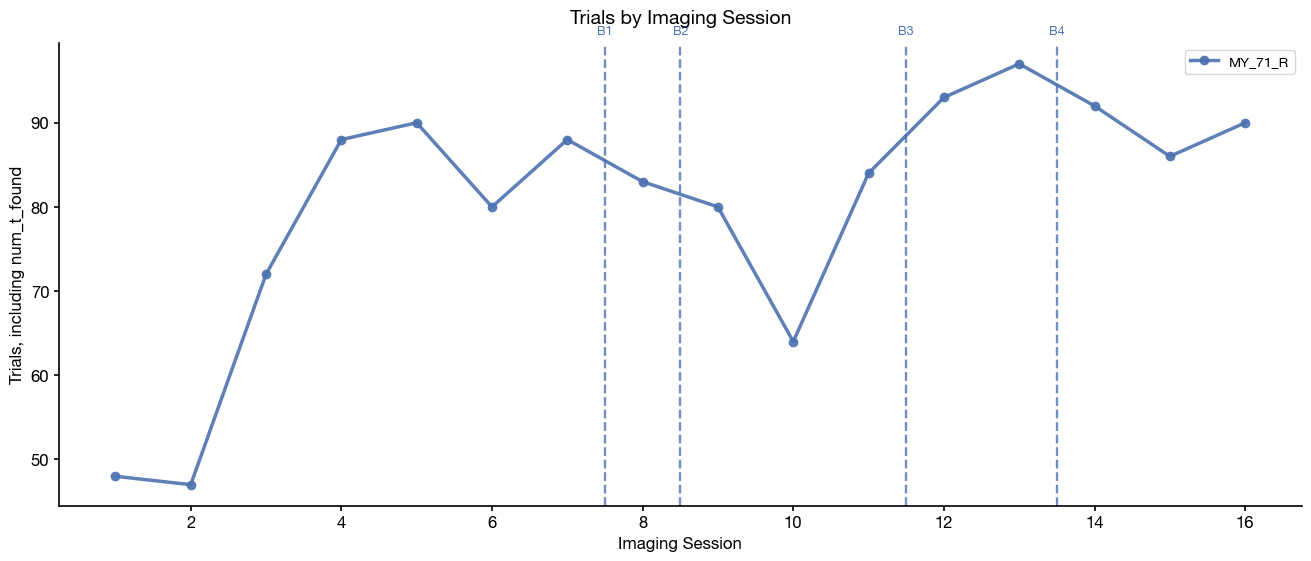

In [133]:
if session_summary.empty:
    print("No complete sessions to plot after the date filter.")
else:
    if not break_table.empty:
        print("Breaks shown as dashed vertical lines:")
        display_break_table(break_table)

    colors = subject_color_map(session_summary)
    fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)

    for subject_key, subject_table in session_summary.groupby("subject_key", sort=True):
        subject_table = subject_table.sort_values("imaging_session")
        ax.plot(
            subject_table["imaging_session"],
            subject_table["num_trials_including_num_t_found"],
            marker="o",
            markersize=6,
            linewidth=2.5,
            alpha=0.9,
            color=colors[subject_key],
            label=subject_key.split("_id-")[1],
        )

    overlay_dummy_scope_points(
        ax,
        session_summary,
        "imaging_session",
        "num_trials_including_num_t_found",
    )
    add_dummy_scope_start_lines(ax, session_summary, "imaging_session")

    if not break_table.empty:
        session_breaks = break_table.copy()
        session_breaks["x_position"] = (
            session_breaks["from_imaging_session"] + session_breaks["to_imaging_session"]
        ) / 2
        add_break_lines(ax, session_breaks, "x_position", colors=colors)

    ax.set_title("Trials by Imaging Session", pad=14)
    ax.set_xlabel("Imaging Session")
    ax.set_ylabel("Trials, including num_t_found")
    style_rank_like_axis(ax)
    ax.legend(fontsize=10, loc="upper right")
    plt.show()

## Trials By Imaging Day

Trials are summed across sessions within each mouse-relative imaging day.

Breaks shown as dashed vertical lines:


,break_marker,subject_key,from_ses_id,to_ses_id,n_behav_only_sessions,n_behav_only_days,no_session_days,break_note
0,B1,sub-03_id-MY_71_R,ses-222_date-20260805,ses-223_date-20260807,0,0,1,no sessions for 1 days
1,B2,sub-03_id-MY_71_R,ses-223_date-20260807,ses-224_date-20260809,0,0,1,no sessions for 1 days
2,B3,sub-03_id-MY_71_R,ses-226_date-20260811,ses-227_date-20260813,0,0,1,no sessions for 1 days
3,B4,sub-03_id-MY_71_R,ses-228_date-20260814,ses-229_date-20260816,0,0,1,no sessions for 1 days


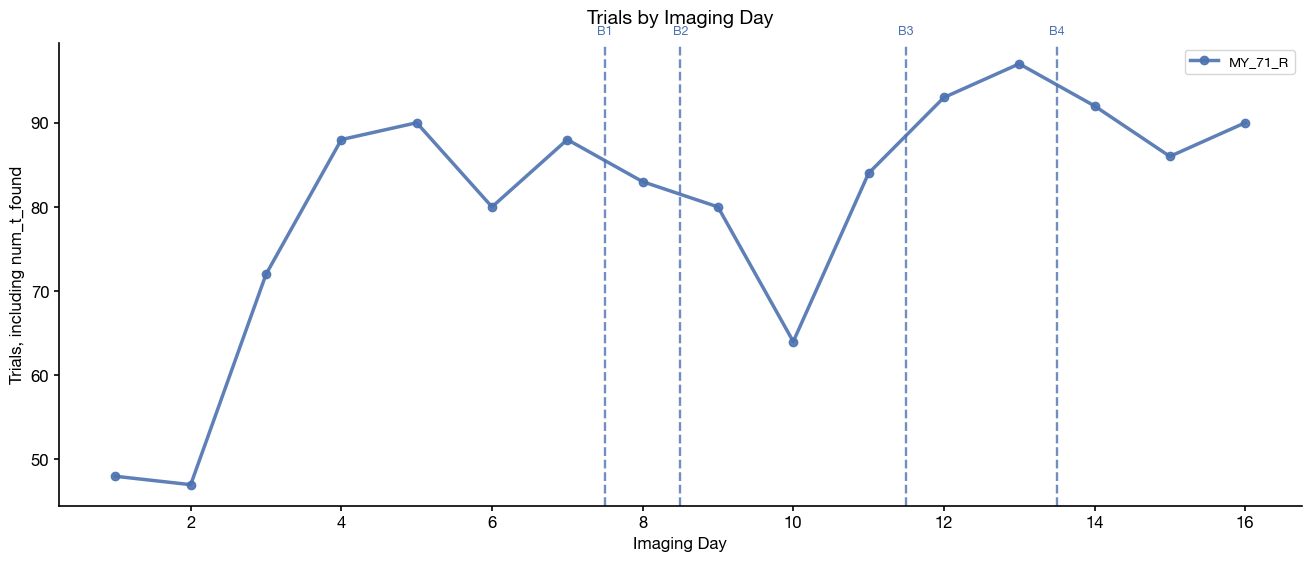

In [134]:
if session_summary.empty:
    print("No complete sessions to plot after the date filter.")
else:
    if not break_table.empty:
        print("Breaks shown as dashed vertical lines:")
        display_break_table(break_table)

    colors = subject_color_map(session_summary)
    daily_trials = (
        session_summary
        .groupby(["subject_key", "imaging_day"], as_index=False)
        .agg(
            num_trials_including_num_t_found=("num_trials_including_num_t_found", "sum"),
            has_dummy_scope=("session_modality", lambda x: x.eq("behav only, dummy scope").any()),
        )
        .sort_values(["subject_key", "imaging_day"])
    )

    fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
    for subject_key, subject_table in daily_trials.groupby("subject_key", sort=True):
        ax.plot(
            subject_table["imaging_day"],
            subject_table["num_trials_including_num_t_found"],
            marker="o",
            markersize=6,
            linewidth=2.5,
            alpha=0.9,
            color=colors[subject_key],
            label=subject_key.split("_id-")[1],
        )

    dummy_days = daily_trials[daily_trials["has_dummy_scope"]].copy()
    if not dummy_days.empty:
        ax.scatter(
            dummy_days["imaging_day"],
            dummy_days["num_trials_including_num_t_found"],
            s=70,
            color=DUMMY_SCOPE_COLOR,
            edgecolor="black",
            linewidth=1.0,
            zorder=5,
            label="Dummyscope Day",
        )
    add_dummy_scope_start_lines(ax, session_summary, "imaging_day")

    if not break_table.empty:
        day_breaks = break_table.copy()
        day_breaks["x_position"] = (
            day_breaks["from_imaging_day"] + day_breaks["to_imaging_day"]
        ) / 2
        add_break_lines(ax, day_breaks, "x_position", colors=colors)

    ax.set_title("Trials by Imaging Day", pad=14)
    ax.set_xlabel("Imaging Day")
    ax.set_ylabel("Trials, including num_t_found")
    style_rank_like_axis(ax)
    ax.legend(fontsize=10, loc="upper right")
    plt.show()

## Trials By Imaging Day, Unlabeled Break Lines

Breaks shown as unlabeled dashed vertical lines:


,break_marker,subject_key,from_ses_id,to_ses_id,n_behav_only_sessions,n_behav_only_days,no_session_days,break_note
0,B1,sub-03_id-MY_71_R,ses-222_date-20260805,ses-223_date-20260807,0,0,1,no sessions for 1 days
1,B2,sub-03_id-MY_71_R,ses-223_date-20260807,ses-224_date-20260809,0,0,1,no sessions for 1 days
2,B3,sub-03_id-MY_71_R,ses-226_date-20260811,ses-227_date-20260813,0,0,1,no sessions for 1 days
3,B4,sub-03_id-MY_71_R,ses-228_date-20260814,ses-229_date-20260816,0,0,1,no sessions for 1 days


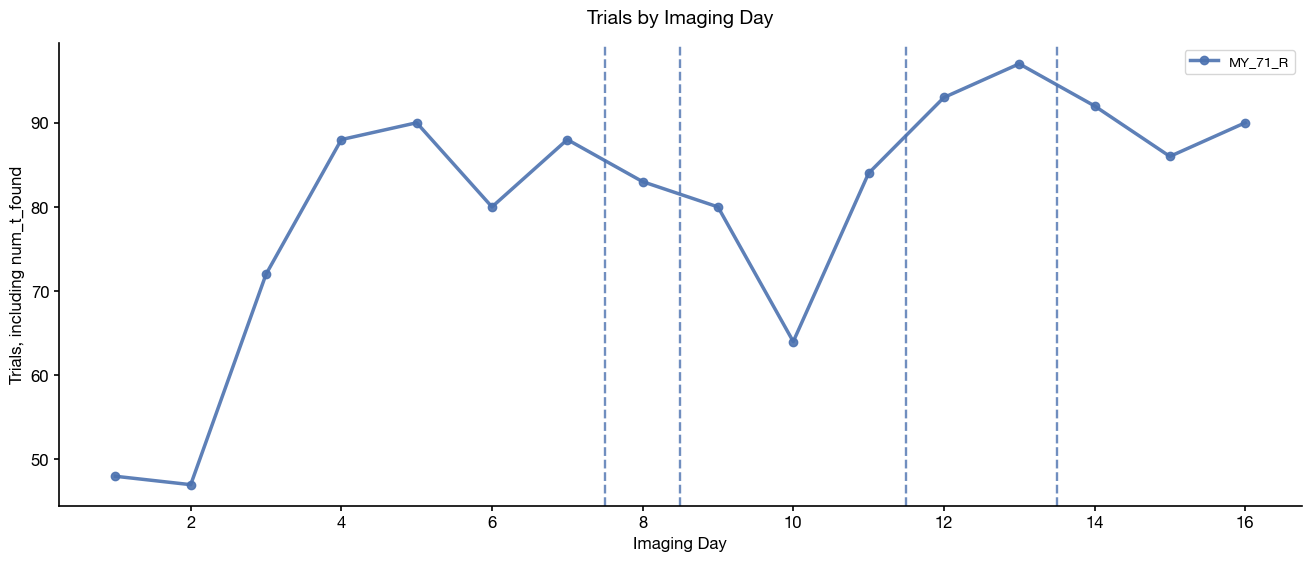

In [135]:
if session_summary.empty:
    print("No complete sessions to plot after the date filter.")
else:
    if not break_table.empty:
        print("Breaks shown as unlabeled dashed vertical lines:")
        display_break_table(break_table)

    colors = subject_color_map(session_summary)
    daily_trials = (
        session_summary
        .groupby(["subject_key", "imaging_day"], as_index=False)
        .agg(
            num_trials_including_num_t_found=("num_trials_including_num_t_found", "sum"),
            has_dummy_scope=("session_modality", lambda x: x.eq("behav only, dummy scope").any()),
        )
        .sort_values(["subject_key", "imaging_day"])
    )

    fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
    for subject_key, subject_table in daily_trials.groupby("subject_key", sort=True):
        ax.plot(
            subject_table["imaging_day"],
            subject_table["num_trials_including_num_t_found"],
            marker="o",
            markersize=6,
            linewidth=2.5,
            alpha=0.9,
            color=colors[subject_key],
            label=subject_key.split("_id-")[1],
        )

    dummy_days = daily_trials[daily_trials["has_dummy_scope"]].copy()
    if not dummy_days.empty:
        ax.scatter(
            dummy_days["imaging_day"],
            dummy_days["num_trials_including_num_t_found"],
            s=70,
            color=DUMMY_SCOPE_COLOR,
            edgecolor="black",
            linewidth=1.0,
            zorder=5,
            label="Dummyscope Day",
        )
    add_dummy_scope_start_lines(ax, session_summary, "imaging_day")

    if not break_table.empty:
        day_breaks = break_table.copy()
        day_breaks["x_position"] = (
            day_breaks["from_imaging_day"] + day_breaks["to_imaging_day"]
        ) / 2
        for _, row in day_breaks.dropna(subset=["x_position"]).iterrows():
            ax.axvline(
                row["x_position"],
                color=colors.get(row["subject_key"], "0.65"),
                linestyle="--",
                linewidth=1.7,
                alpha=0.8,
                zorder=0,
            )

    ax.set_title("Trials by Imaging Day", pad=14)
    ax.set_xlabel("Imaging Day")
    ax.set_ylabel("Trials, including num_t_found")
    style_rank_like_axis(ax)
    ax.legend(fontsize=10, loc="upper right")
    plt.show()

## Trials By Imaging Day, No Break Lines

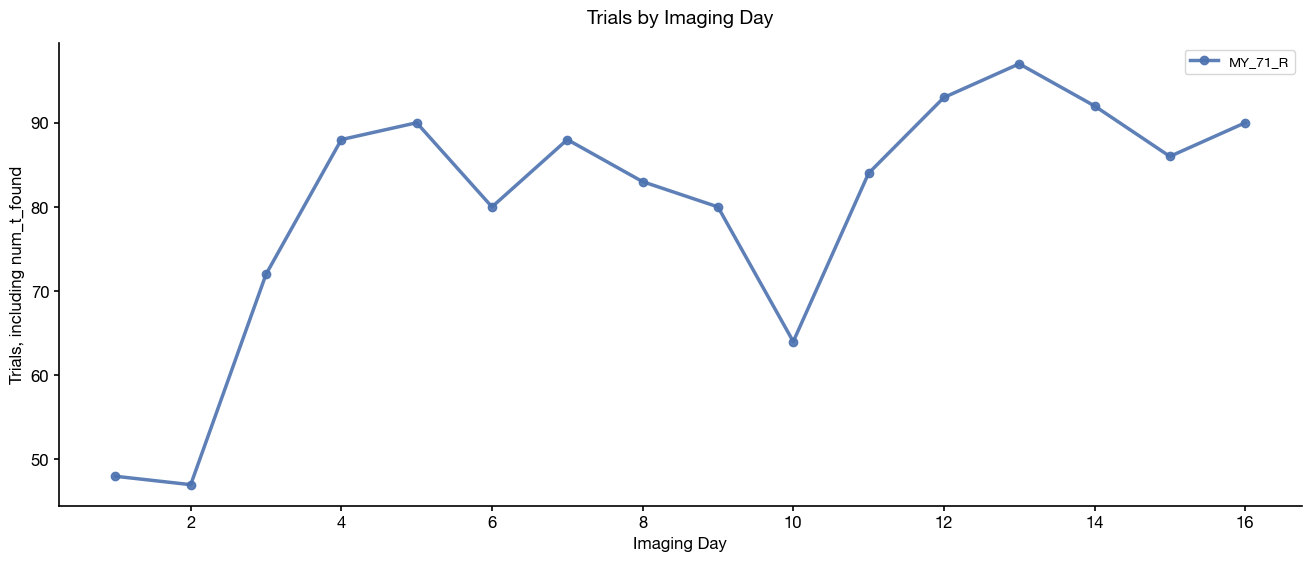

In [136]:
if session_summary.empty:
    print("No complete sessions to plot after the date filter.")
else:
    colors = subject_color_map(session_summary)
    daily_trials = (
        session_summary
        .groupby(["subject_key", "imaging_day"], as_index=False)
        .agg(
            num_trials_including_num_t_found=("num_trials_including_num_t_found", "sum"),
            has_dummy_scope=("session_modality", lambda x: x.eq("behav only, dummy scope").any()),
        )
        .sort_values(["subject_key", "imaging_day"])
    )

    fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
    for subject_key, subject_table in daily_trials.groupby("subject_key", sort=True):
        ax.plot(
            subject_table["imaging_day"],
            subject_table["num_trials_including_num_t_found"],
            marker="o",
            markersize=6,
            linewidth=2.5,
            alpha=0.9,
            color=colors[subject_key],
            label=subject_key.split("_id-")[1],
        )

    dummy_days = daily_trials[daily_trials["has_dummy_scope"]].copy()
    if not dummy_days.empty:
        ax.scatter(
            dummy_days["imaging_day"],
            dummy_days["num_trials_including_num_t_found"],
            s=70,
            color=DUMMY_SCOPE_COLOR,
            edgecolor="black",
            linewidth=1.0,
            zorder=5,
            label="Dummyscope Day",
        )
    add_dummy_scope_start_lines(ax, session_summary, "imaging_day")

    ax.set_title("Trials by Imaging Day", pad=14)
    ax.set_xlabel("Imaging Day")
    ax.set_ylabel("Trials, including num_t_found")
    style_rank_like_axis(ax)
    ax.legend(fontsize=10, loc="upper right")
    plt.show()

## Trials By Imaging Day, Unlabeled Break Lines And No Dummy-Scope Lines

Breaks shown as unlabeled dashed vertical lines:


,break_marker,subject_key,from_ses_id,to_ses_id,n_behav_only_sessions,n_behav_only_days,no_session_days,break_note
0,B1,sub-03_id-MY_71_R,ses-222_date-20260805,ses-223_date-20260807,0,0,1,no sessions for 1 days
1,B2,sub-03_id-MY_71_R,ses-223_date-20260807,ses-224_date-20260809,0,0,1,no sessions for 1 days
2,B3,sub-03_id-MY_71_R,ses-226_date-20260811,ses-227_date-20260813,0,0,1,no sessions for 1 days
3,B4,sub-03_id-MY_71_R,ses-228_date-20260814,ses-229_date-20260816,0,0,1,no sessions for 1 days


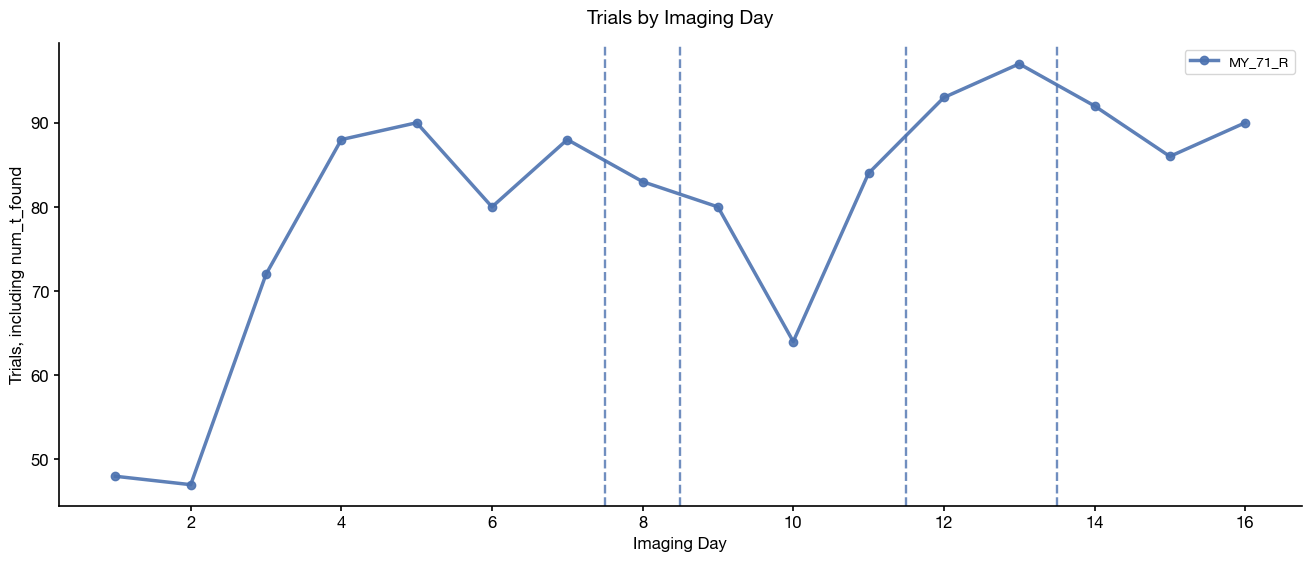

In [137]:
if session_summary.empty:
    print("No complete sessions to plot after the date filter.")
else:
    if not break_table.empty:
        print("Breaks shown as unlabeled dashed vertical lines:")
        display_break_table(break_table)

    colors = subject_color_map(session_summary)
    daily_trials = (
        session_summary
        .groupby(["subject_key", "imaging_day"], as_index=False)
        .agg(
            num_trials_including_num_t_found=("num_trials_including_num_t_found", "sum"),
            has_dummy_scope=("session_modality", lambda x: x.eq("behav only, dummy scope").any()),
        )
        .sort_values(["subject_key", "imaging_day"])
    )

    fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
    for subject_key, subject_table in daily_trials.groupby("subject_key", sort=True):
        ax.plot(
            subject_table["imaging_day"],
            subject_table["num_trials_including_num_t_found"],
            marker="o",
            markersize=6,
            linewidth=2.5,
            alpha=0.9,
            color=colors[subject_key],
            label=subject_key.split("_id-")[1],
        )

    dummy_days = daily_trials[daily_trials["has_dummy_scope"]].copy()
    if not dummy_days.empty:
        ax.scatter(
            dummy_days["imaging_day"],
            dummy_days["num_trials_including_num_t_found"],
            s=70,
            color=DUMMY_SCOPE_COLOR,
            edgecolor="black",
            linewidth=1.0,
            zorder=5,
            label="Dummy-scope day",
        )

    if not break_table.empty:
        day_breaks = break_table.copy()
        day_breaks["x_position"] = (
            day_breaks["from_imaging_day"] + day_breaks["to_imaging_day"]
        ) / 2
        for _, row in day_breaks.dropna(subset=["x_position"]).iterrows():
            ax.axvline(
                row["x_position"],
                color=colors.get(row["subject_key"], "0.65"),
                linestyle="--",
                linewidth=1.7,
                alpha=0.8,
                zorder=0,
            )

    ax.set_title("Trials by Imaging Day", pad=14)
    ax.set_xlabel("Imaging Day")
    ax.set_ylabel("Trials, including num_t_found")
    style_rank_like_axis(ax)
    ax.legend(fontsize=10, loc="upper right")
    plt.show()

## Trials By Imaging Day, No Vertical Lines

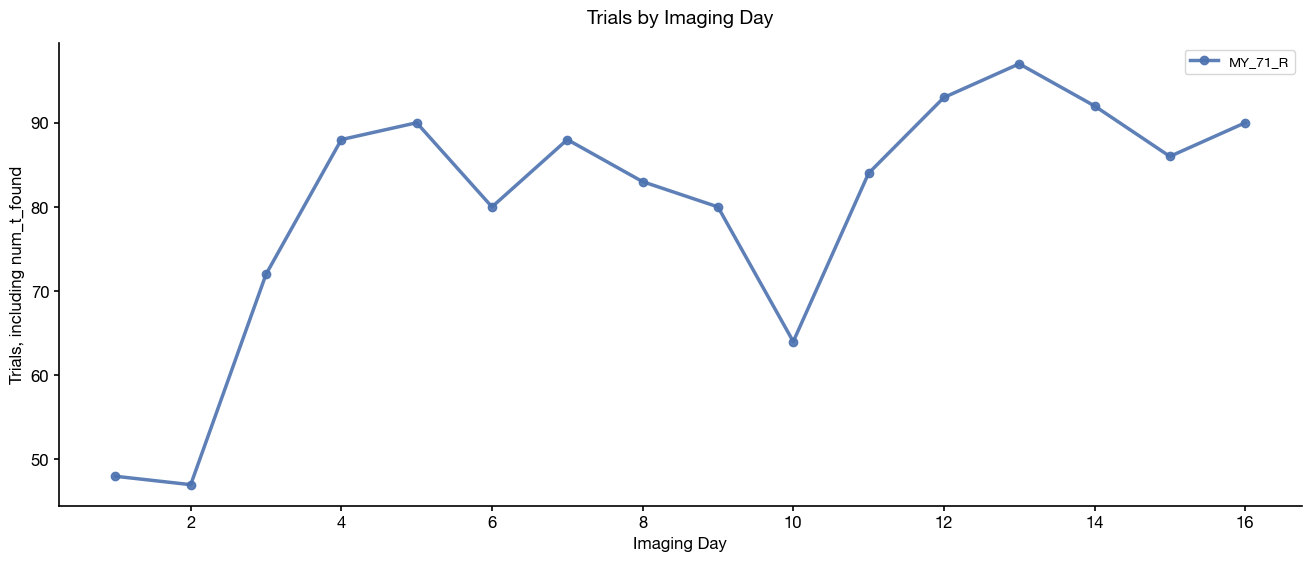

In [138]:
if session_summary.empty:
    print("No complete sessions to plot after the date filter.")
else:
    colors = subject_color_map(session_summary)
    daily_trials = (
        session_summary
        .groupby(["subject_key", "imaging_day"], as_index=False)
        .agg(
            num_trials_including_num_t_found=("num_trials_including_num_t_found", "sum"),
        )
        .sort_values(["subject_key", "imaging_day"])
    )

    fig, ax = plt.subplots(figsize=(13, 5.5), constrained_layout=True)
    for subject_key, subject_table in daily_trials.groupby("subject_key", sort=True):
        ax.plot(
            subject_table["imaging_day"],
            subject_table["num_trials_including_num_t_found"],
            marker="o",
            markersize=6,
            linewidth=2.5,
            alpha=0.9,
            color=colors[subject_key],
            label=subject_key.split("_id-")[1],
        )

    ax.set_title("Trials by Imaging Day", pad=14)
    ax.set_xlabel("Imaging Day")
    ax.set_ylabel("Trials, including num_t_found")
    style_rank_like_axis(ax)
    ax.legend(fontsize=10, loc="upper right")
    plt.show()


## Imaging Signature Mapping

Problem signatures are labeled relative to each mouse. The first unique imaging problem for each mouse is `imaging signature 1`, the next unique imaging problem is `imaging signature 2`, and so on.

In [139]:
if session_summary.empty:
    signature_summary = pd.DataFrame()
    signature_order = []
    print("No complete sessions to summarize after the date filter.")
else:
    signature_summary = session_summary.copy()
    signature_order = [
        f"imaging signature {i}"
        for i in range(1, int(signature_summary["imaging_signature_number"].max()) + 1)
    ]
    signature_summary["imaging_signature"] = pd.Categorical(
        signature_summary["imaging_signature"],
        categories=signature_order,
        ordered=True,
    )
    signature_lookup = (
        signature_summary[["subject_key", "imaging_signature_number", "imaging_signature", "problem_signature"]]
        .drop_duplicates()
        .sort_values(["subject_key", "imaging_signature_number"])
        .reset_index(drop=True)
    )
    display(signature_lookup)

,subject_key,imaging_signature_number,imaging_signature,problem_signature
0,sub-03_id-MY_71_R,1,imaging signature 1,init=B2; choices=A1+C1+C3
1,sub-03_id-MY_71_R,2,imaging signature 2,init=B2; choices=A2+B1+C2
2,sub-03_id-MY_71_R,3,imaging signature 3,init=B2; choices=A1+B3+C1
3,sub-03_id-MY_71_R,4,imaging signature 4,init=B2; choices=A2+B1+C3
4,sub-03_id-MY_71_R,5,imaging signature 5,init=B2; choices=B1+B3+C2


## Single-Session Plots With Sessions Concatenated By Imaging Problem

Plotting MY_71_R | imaging signature 1 | 4 sessions concatenated | 242 trials | init=B2; choices=A1+C1+C3


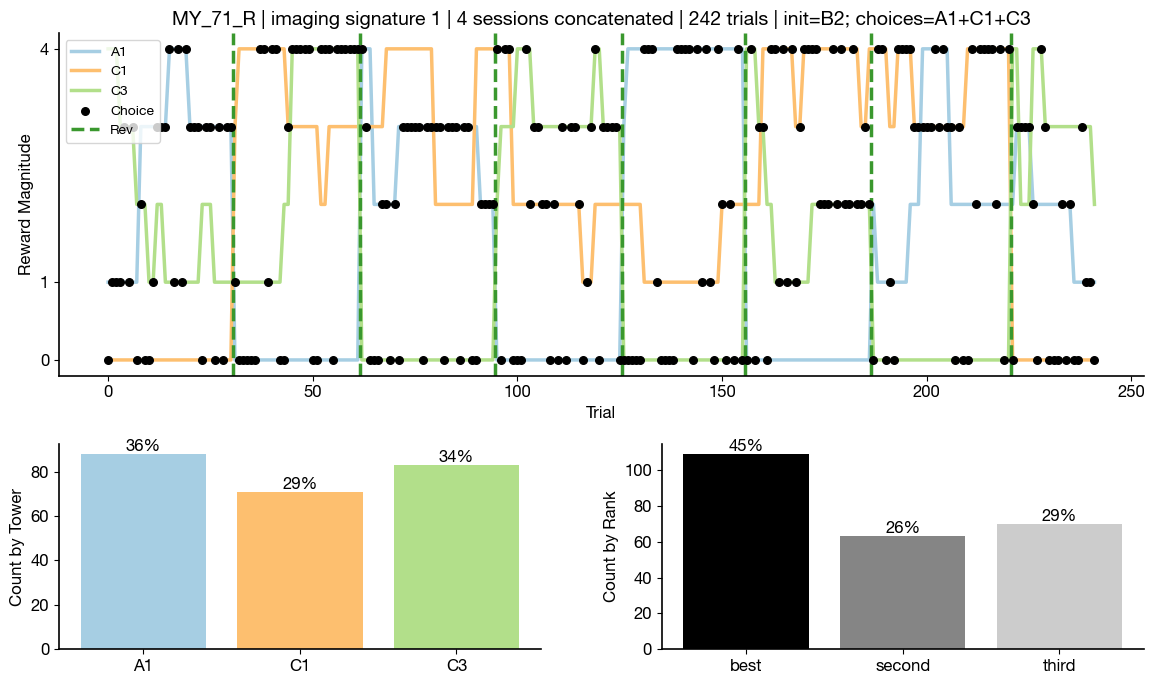

Plotting MY_71_R | imaging signature 2 | 3 sessions concatenated | 246 trials | init=B2; choices=A2+B1+C2


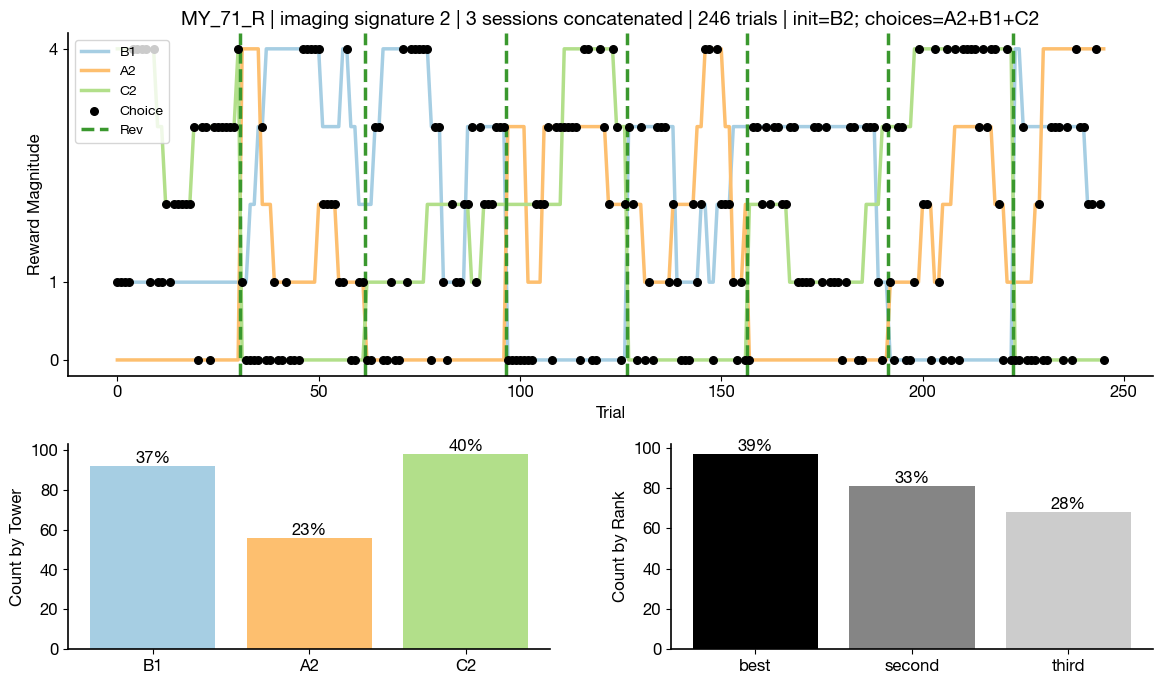

Plotting MY_71_R | imaging signature 3 | 3 sessions concatenated | 219 trials | init=B2; choices=A1+B3+C1


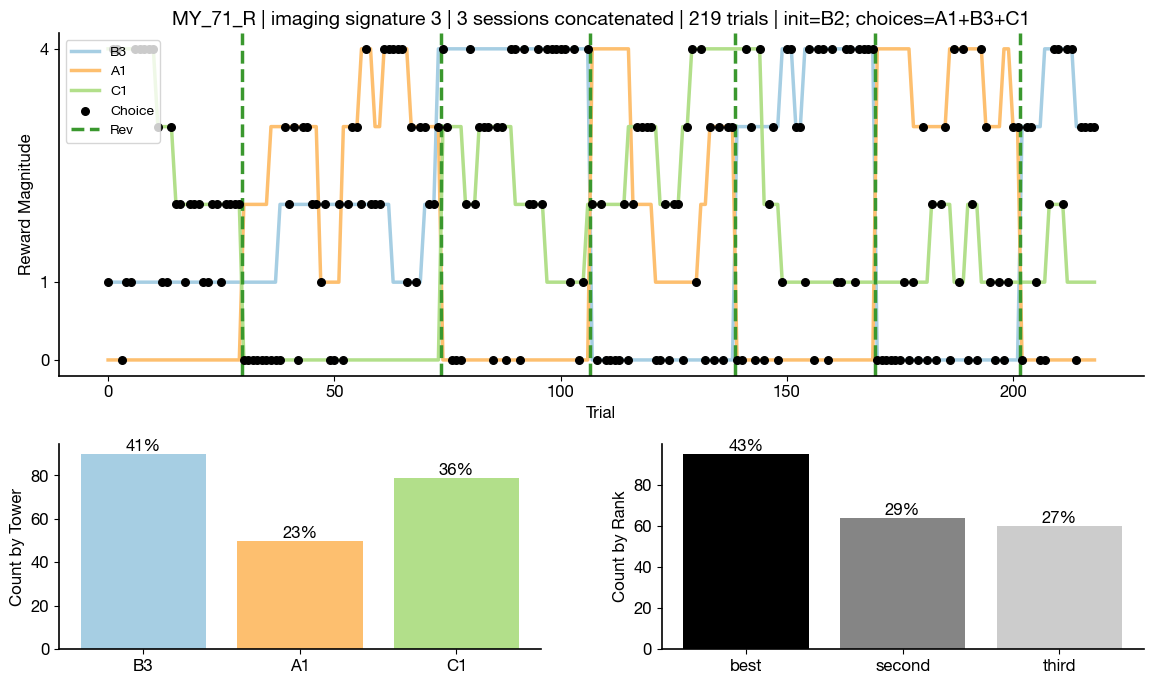

Plotting MY_71_R | imaging signature 4 | 3 sessions concatenated | 257 trials | init=B2; choices=A2+B1+C3


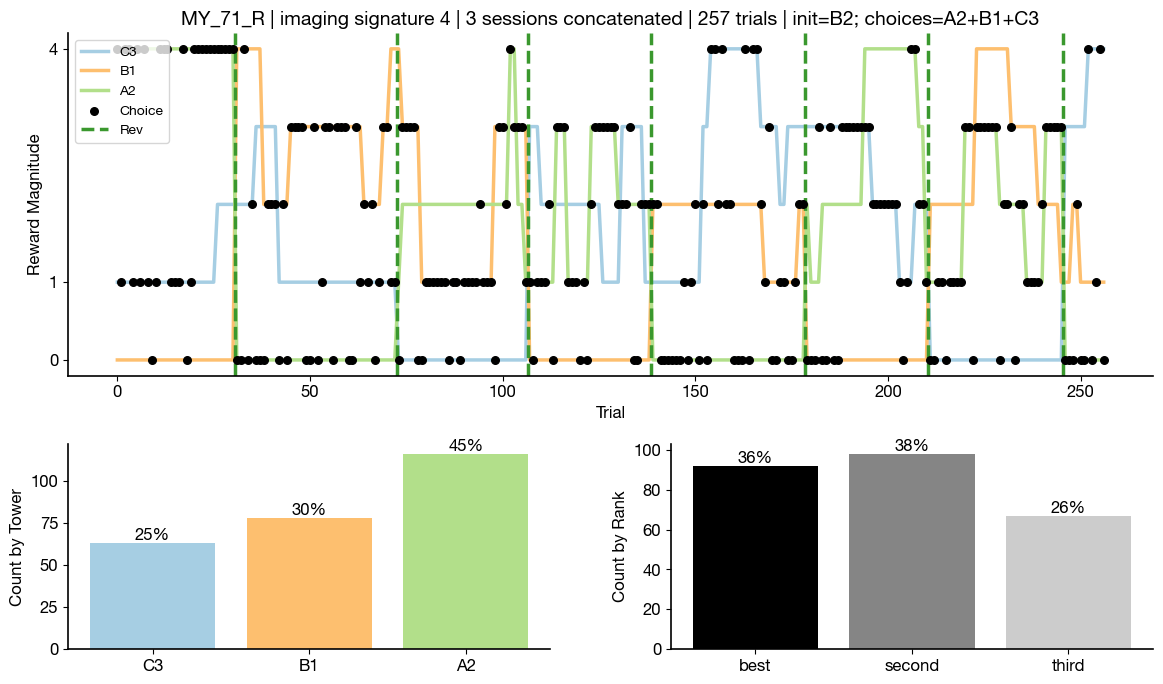

Plotting MY_71_R | imaging signature 5 | 3 sessions concatenated | 259 trials | init=B2; choices=B1+B3+C2


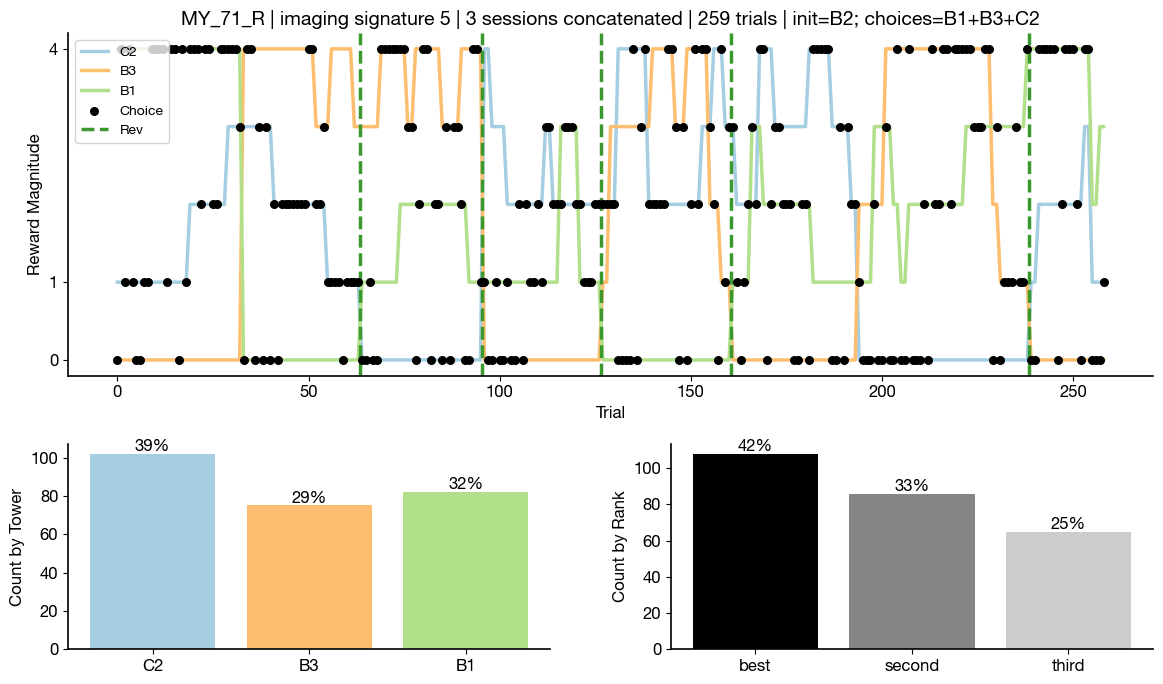

In [140]:
SAVE_CONCATENATED_PROBLEM_SESSION_PLOTS = False
CONCATENATED_PROBLEM_SESSION_SAVE_ROOT = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / task
    / cohort
    / "concatenated-problem-sessions"
)


def build_imaging_signature_trial_groups_for_single_session_plots(subjects_trials_by_problem, session_summary):
    if not subjects_trials_by_problem or session_summary.empty:
        return {}

    imaging_lookup = {
        (row["subject_id"], row["ses_id"]): row["imaging_signature"]
        for _, row in session_summary.iterrows()
    }

    categories = getattr(session_summary["imaging_signature"], "cat", None)
    if categories is not None:
        groups = {signature: {} for signature in session_summary["imaging_signature"].cat.categories}
    else:
        groups = {signature: {} for signature in session_summary["imaging_signature"].dropna().unique()}

    for _, problem_subjects in subjects_trials_by_problem.items():
        for subject_id, subject_sessions in problem_subjects.items():
            for ses_id, session_data in subject_sessions.items():
                signature = imaging_lookup.get((subject_id, ses_id))
                if signature is None or not session_data.get("trial_info"):
                    continue
                groups.setdefault(signature, {}).setdefault(subject_id, {})[ses_id] = session_data

    return {signature: subjects for signature, subjects in groups.items() if subjects}


def add_rank_counts_from_choices_by_rank(session_data):
    choices_by_rank = session_data.get("choices_by_rank") or {}
    rank_keys = [rank for rank in ("best", "second", "third") if rank in choices_by_rank]
    if not rank_keys:
        return session_data

    n_trials = max((len(choices_by_rank[rank]) for rank in rank_keys), default=0)
    cumulative = {rank: 0 for rank in rank_keys}
    rank_counts = []

    for i in range(n_trials):
        for rank in rank_keys:
            if i < len(choices_by_rank[rank]) and choices_by_rank[rank][i]:
                cumulative[rank] += int(choices_by_rank[rank][i])
        rank_counts.append(cumulative.copy())

    session_data["rank_counts"] = rank_counts
    return session_data


def concatenate_problem_sessions(subjects_trials):
    merged_subjects, _ = get_vars_across_all_sessions(subjects_trials)
    out = {}
    for subject_id, merged_session in merged_subjects.items():
        merged_session = add_rank_counts_from_choices_by_rank(merged_session)
        out[subject_id] = merged_session
    return out


if session_summary.empty:
    print("No included imaging sessions to plot after the date filter.")
else:
    concatenated_plot_groups = build_imaging_signature_trial_groups_for_single_session_plots(
        subjects_trials_by_problem,
        signature_summary,
    )

    if not concatenated_plot_groups:
        print("No trial groups found for concatenated problem-session plots.")
    else:
        for imaging_signature in signature_order:
            subjects_trials = concatenated_plot_groups.get(imaging_signature)
            if not subjects_trials:
                continue

            signature_rows = signature_summary[
                signature_summary["imaging_signature"].eq(imaging_signature)
            ]
            if signature_rows.empty:
                problem_signature = "unknown"
                imaging_signature_number = imaging_signature.split()[-1]
            else:
                problem_signature = signature_rows["problem_signature"].iloc[0]
                imaging_signature_number = int(signature_rows["imaging_signature_number"].iloc[0])

            concatenated_subject_sessions = concatenate_problem_sessions(subjects_trials)
            for subject_id, concatenated_session in concatenated_subject_sessions.items():
                n_trials = len(next(iter(concatenated_session.get("reward_magnitudes_by_tower", {"": []}).values())))
                n_sessions = len(subjects_trials.get(subject_id, {}))
                title = (
                    f"{subject_id} | {imaging_signature} | {n_sessions} sessions concatenated | "
                    f"{n_trials} trials | {problem_signature}"
                )
                print(f"Plotting {title}")

                save_path = None
                if SAVE_CONCATENATED_PROBLEM_SESSION_PLOTS:
                    save_path = (
                        CONCATENATED_PROBLEM_SESSION_SAVE_ROOT
                        / f"imaging-signature-{imaging_signature_number:02d}"
                        / subject_id
                        / "Concatenated Problem Session Plot"
                    )

                plot_single_session(
                    concatenated_session,
                    title=title,
                    save_path=save_path,
                )


## Trials By Imaging Signature

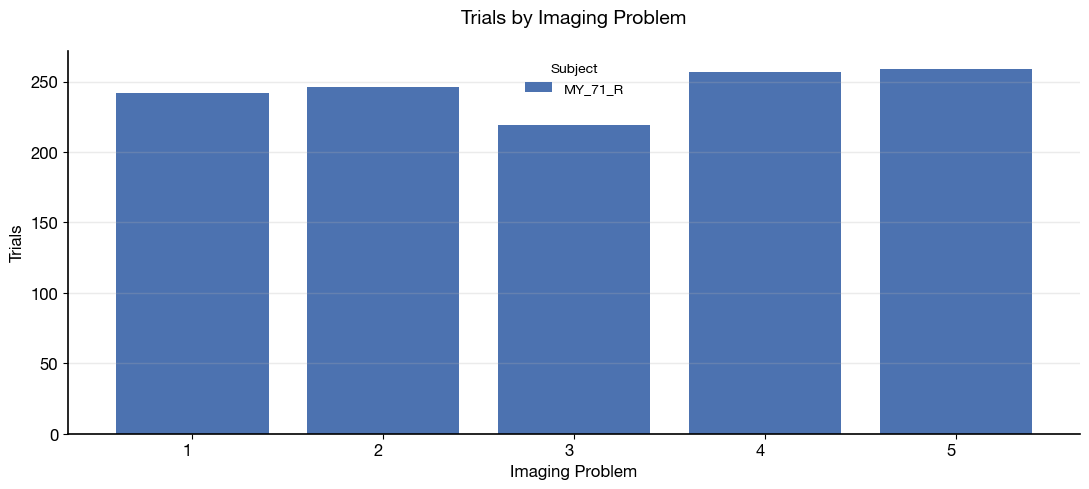

In [141]:
if session_summary.empty:
    print("No complete sessions to plot after the date filter.")
else:
    trials_by_signature = (
        signature_summary
        .groupby(
            ["imaging_signature", "subject_key"],
            as_index=False,
            observed=True
        )["num_trials_excluding_num_t_found"]
        .sum()
    )

    plot_df = trials_by_signature.pivot(
        index="imaging_signature",
        columns="subject_key",
        values="num_trials_excluding_num_t_found",
    ).reindex(signature_order).fillna(0)

    # Clean subject labels
    plot_df.columns = [
        col.split("_id-")[-1]
        for col in plot_df.columns
    ]

    # Clean color map keys
    colors_raw = subject_color_map(session_summary)
    colors = {
        k.split("_id-")[-1]: v
        for k, v in colors_raw.items()
    }

    bar_colors = [colors[col] for col in plot_df.columns]

    ax = plot_df.plot(
        kind="bar",
        figsize=(11, 5),
        width=0.8,
        color=bar_colors,
    )

    ax.set_title("Trials by Imaging Problem", y=1.05)
    ax.set_xlabel("Imaging Problem")
    ax.set_ylabel("Trials")

    style_summary_axis(ax)

    ax.set_xticks(range(len(plot_df.index)))
    ax.set_xticklabels(
        [f"{i+1}" for i in range(len(plot_df.index))],
        rotation=0,
        ha="right",
    )

    ax.legend(title="Subject", frameon=False)

    plt.tight_layout()
    plt.show()

## Days By Imaging Signature

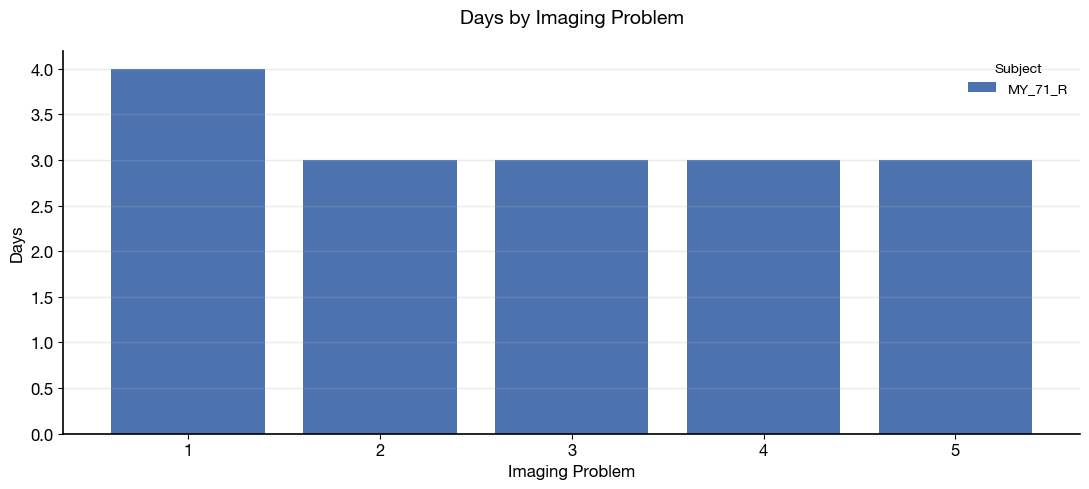

In [142]:
if session_summary.empty:
    print("No included imaging sessions to plot after the date filter.")
else:
    days_by_signature = (
        signature_summary
        .drop_duplicates(["imaging_signature", "subject_key", "date"])
        .groupby(
            ["imaging_signature", "subject_key"],
            as_index=False,
            observed=True,
        )
        .size()
        .rename(columns={"size": "num_days"})
    )

    plot_df = days_by_signature.pivot(
        index="imaging_signature",
        columns="subject_key",
        values="num_days",
    ).reindex(signature_order).fillna(0)

    # Clean subject labels.
    plot_df.columns = [
        col.split("_id-")[-1]
        for col in plot_df.columns
    ]

    # Clean color map keys the same way.
    colors_raw = subject_color_map(session_summary)
    colors = {
        k.split("_id-")[-1]: v
        for k, v in colors_raw.items()
    }
    bar_colors = [colors[col] for col in plot_df.columns]

    ax = plot_df.plot(
        kind="bar",
        figsize=(11, 5),
        width=0.8,
        color=bar_colors,
    )

    ax.set_title("Days by Imaging Problem", y=1.05)
    ax.set_xlabel("Imaging Problem")
    ax.set_ylabel("Days")

    style_summary_axis(ax)

    ax.set_xticks(range(len(plot_df.index)))
    ax.set_xticklabels(
        [f"{i + 1}" for i in range(len(plot_df.index))],
        rotation=0,
        ha="center",
    )

    ax.legend(title="Subject", frameon=False)

    plt.tight_layout()
    plt.show()

## Rank Proportions By Imaging Signature

This runs the existing `plot_rank_proportions` analysis separately for each mouse-relative imaging signature. The input is filtered to included imaging sessions: real `behav+funcimg` sessions plus `behav`-only dummy-scope sessions on or after `DUMMY_SCOPE_START_DATE`. Earlier behavior-only sessions are excluded.


imaging signature 1: 1 subjects, 4 imaging sessions
Rank-proportion windows: 8


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


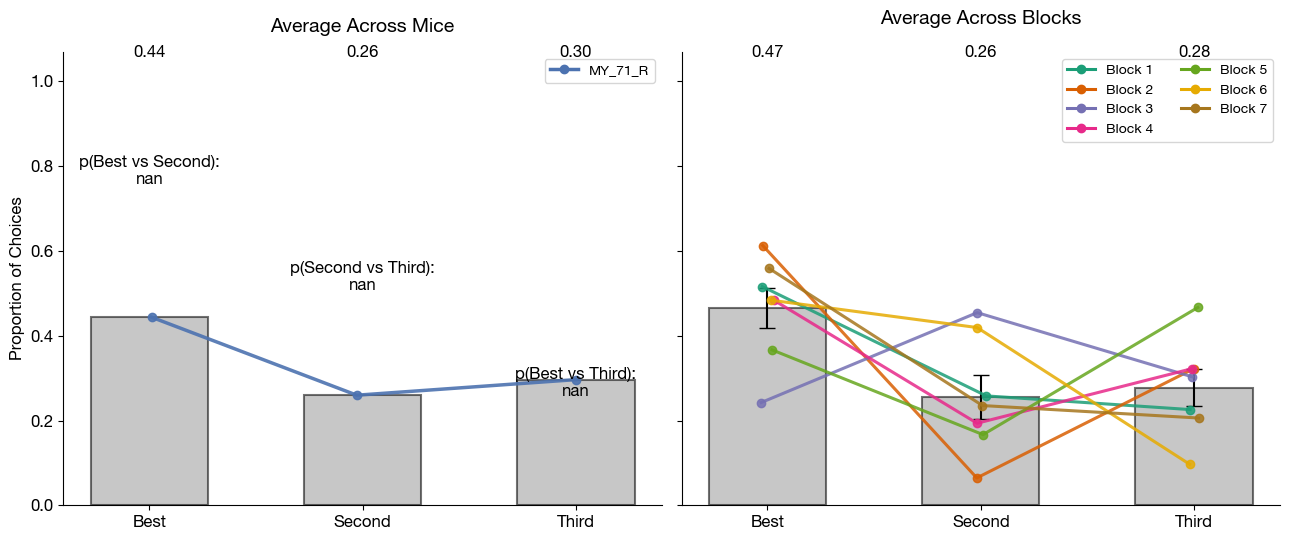


imaging signature 2: 1 subjects, 3 imaging sessions
Rank-proportion windows: 8


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


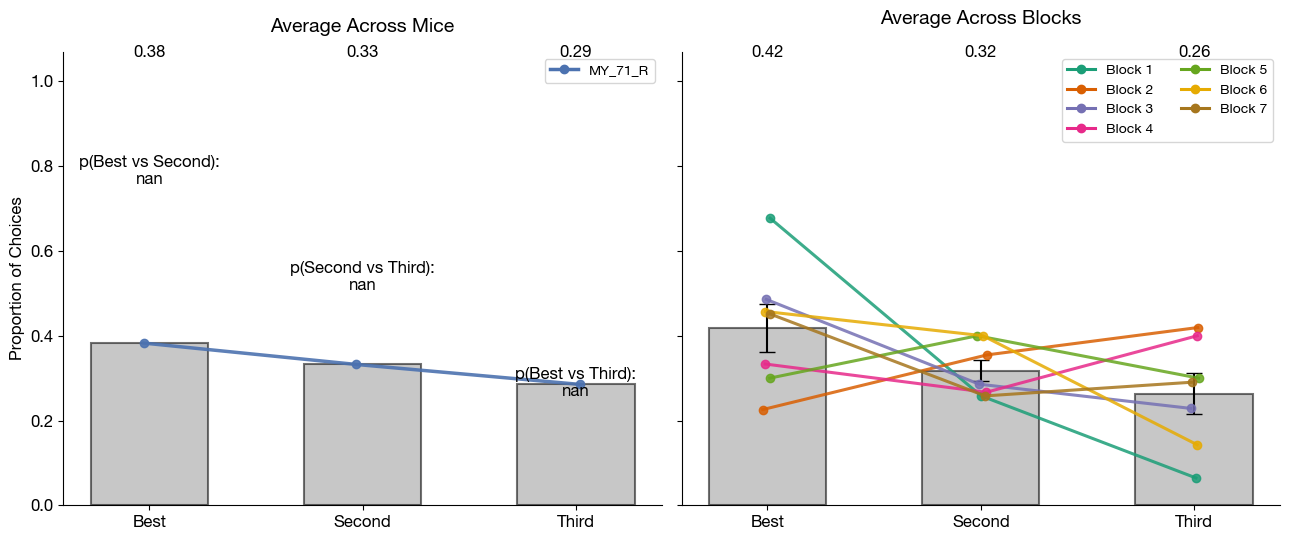


imaging signature 3: 1 subjects, 3 imaging sessions
Rank-proportion windows: 7


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


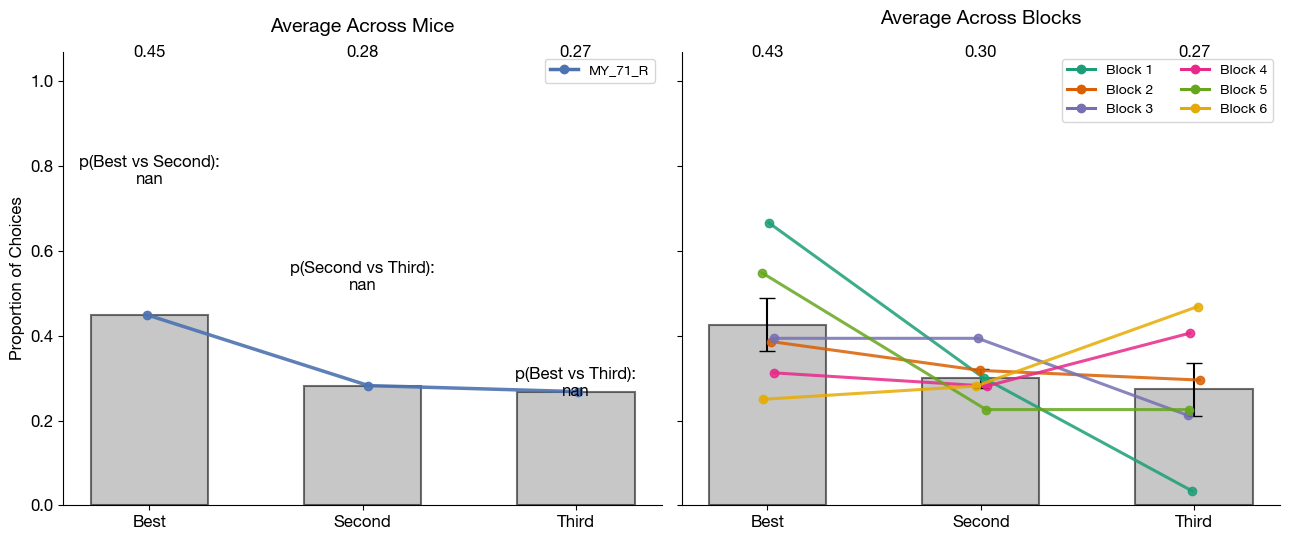


imaging signature 4: 1 subjects, 3 imaging sessions
Rank-proportion windows: 8


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


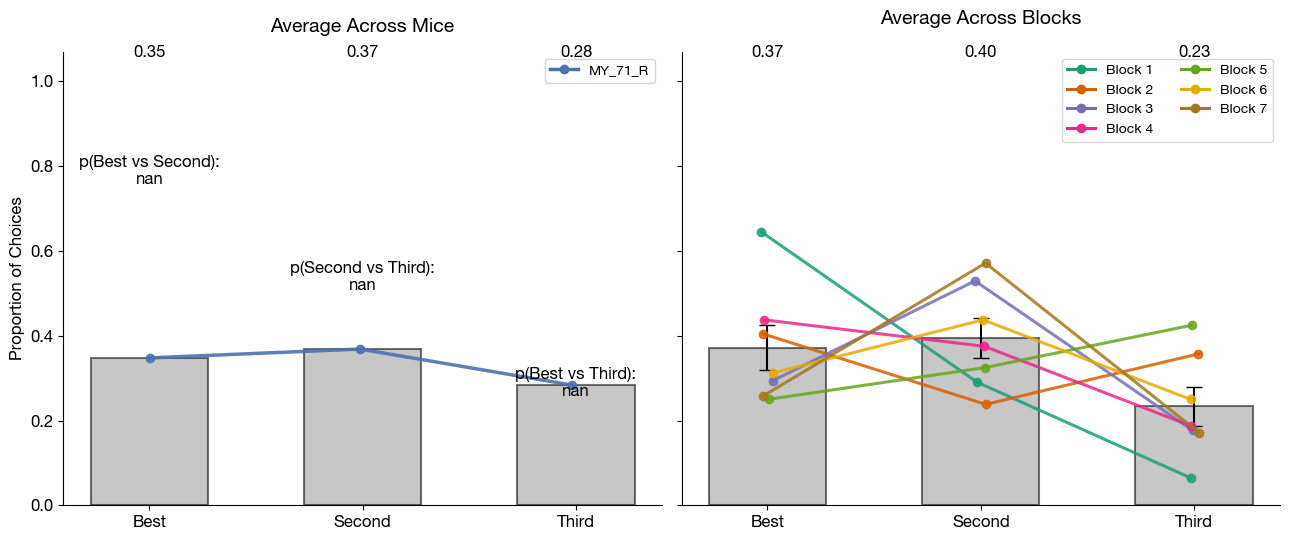


imaging signature 5: 1 subjects, 3 imaging sessions
Rank-proportion windows: 6


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


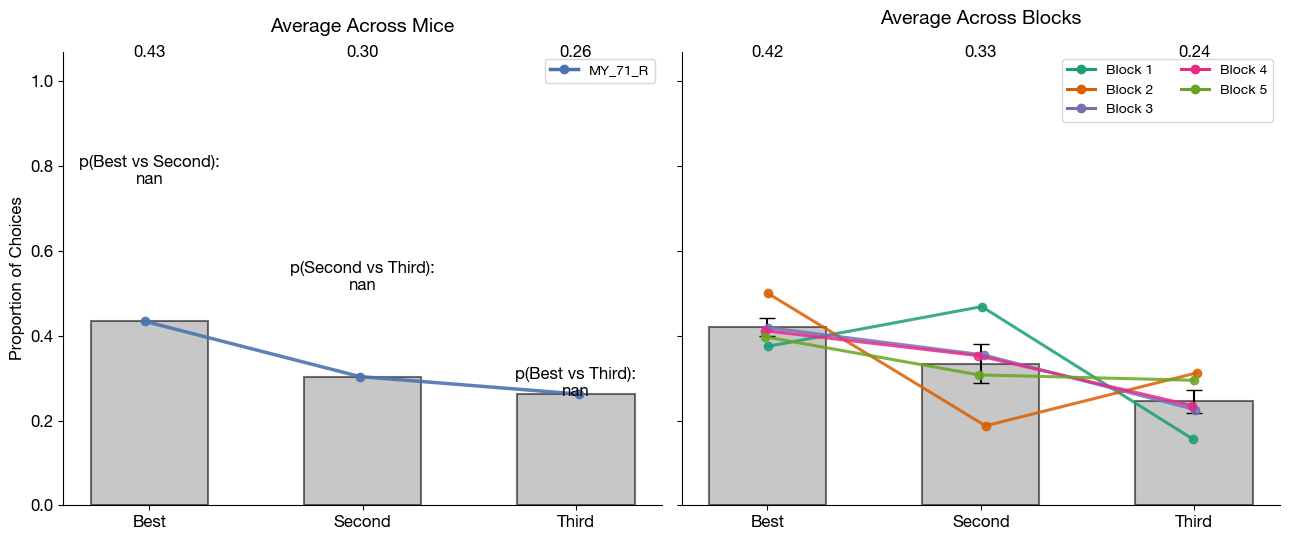

In [143]:
RANK_PRE = 5
RANK_POST = None
RANK_INCLUDE_FIRST_BLOCK = True
RANK_PLOT_BY_MOUSE = False
RANK_PLOT_BY_BLOCK = False
RANK_PLOT_AVERAGE = True


def extended_rank_problem_colors(n_colors):
    cmap_names = ["tab20", "tab20b", "tab20c", "Set3", "Dark2"]
    colors = []
    for cmap_name in cmap_names:
        cmap = plt.get_cmap(cmap_name)
        if hasattr(cmap, "colors"):
            colors.extend([cmap(i) for i in range(len(cmap.colors))])
        else:
            colors.extend([cmap(i / max(n_colors - 1, 1)) for i in range(n_colors)])
        if len(colors) >= n_colors:
            break
    return colors[:n_colors]


def apply_rank_problem_palette(n_lines):
    # plot_rank_proportions uses its module-level MOUSE_COLORS global.
    # Replace it temporarily with a longer categorical palette for mouse/problem breakdown plots.
    plot_rank_proportions.__globals__["MOUSE_COLORS"] = extended_rank_problem_colors(max(n_lines, len(MOUSE_COLORS)))


def restore_mouse_palette():
    plot_rank_proportions.__globals__["MOUSE_COLORS"] = MOUSE_COLORS


def lighten_color(color, amount=0.5):
    import matplotlib.colors as mcolors
    rgb = mcolors.to_rgb(color)
    return tuple((1 - amount) + amount * channel for channel in rgb)


def mouse_problem_color(mouse, problem_number, max_problem_number, mouse_colors):
    base = mouse_colors[mouse]
    if max_problem_number <= 1:
        shade = 0.75
    else:
        shade = 0.35 + 0.55 * ((problem_number - 1) / (max_problem_number - 1))
    return lighten_color(base, amount=shade)


def parse_mouse_problem_key(key):
    key = str(key)
    m = re.search(r"(.+?)\s+(?:Imaging\s+)?Problem\s+(\d+)", key, flags=re.IGNORECASE)
    if m:
        return m.group(1).strip(), int(m.group(2))
    return key, 1


def plot_rank_proportions_mouse_problem_breakdown(rank_counts_by_key, title=None, p_values=None):
    rows_by_key = {k: v for k, v in rank_counts_by_key.items() if v}
    if not rows_by_key:
        print("No rank-proportion rows to plot.")
        return

    parsed = {key: parse_mouse_problem_key(key) for key in rows_by_key}
    mice = sorted({mouse for mouse, _ in parsed.values()})
    max_problem = max(problem for _, problem in parsed.values())
    base_colors = {mouse: MOUSE_COLORS[i % len(MOUSE_COLORS)] for i, mouse in enumerate(mice)}

    labels = ["Best", "Second", "Third"]
    rank_keys = ["best", "second", "third"]
    x = list(range(len(labels)))

    per_key = {}
    for key, rows in rows_by_key.items():
        per_key[key] = {
            rank: float(pd.Series([r.get(f"{rank}_prop") for r in rows], dtype="float64").mean())
            for rank in rank_keys
        }

    means = [float(pd.Series([v[rank] for v in per_key.values()], dtype="float64").mean()) for rank in rank_keys]
    ses = []
    for rank in rank_keys:
        vals = pd.Series([v[rank] for v in per_key.values()], dtype="float64").dropna()
        ses.append(float(vals.std(ddof=1) / (len(vals) ** 0.5)) if len(vals) > 1 else float("nan"))

    fig, ax = plt.subplots(figsize=(7.5, 5.5), constrained_layout=True)
    ax.bar(x, means, yerr=ses, capsize=6, width=0.55, color="#999999", edgecolor="black", linewidth=1.5, alpha=0.55, zorder=0)

    jitter = 0.035
    for idx, (key, values) in enumerate(per_key.items()):
        mouse, problem_number = parsed[key]
        color = mouse_problem_color(mouse, problem_number, max_problem, base_colors)
        y = [values[rank] for rank in rank_keys]
        offsets = [((idx % 5) - 2) * jitter / 2 for _ in x]
        ax.plot([xi + off for xi, off in zip(x, offsets)], y, color=color, linewidth=2.5, marker="o", alpha=0.95, markersize=6)

    for xi, mean in zip(x, means):
        if pd.notna(mean):
            ax.text(xi, 1.05, f"{mean:.2f}", ha="center", va="bottom", fontsize=12)

    if p_values:
        p_bs = p_values.get("best_vs_second")
        p_bt = p_values.get("best_vs_third")
        p_st = p_values.get("second_vs_third")
        if p_bs is not None and pd.notna(p_bs):
            ax.text(x[0], 0.75, f"p(Best vs Second):\n{p_bs:.3f}", ha="center", va="bottom", fontsize=12)
        if p_bt is not None and pd.notna(p_bt):
            ax.text(x[2], 0.25, f"p(Best vs Third):\n{p_bt:.3f}", ha="center", va="bottom", fontsize=12)
        if p_st is not None and pd.notna(p_st):
            ax.text(x[1], 0.5, f"p(Second vs Third):\n{p_st:.3f}", ha="center", va="bottom", fontsize=12)

    legend_handles = [
        Line2D([0], [0], color=base_colors[mouse], lw=2.5, marker="o", label=mouse)
        for mouse in mice
    ]
    ax.legend(handles=legend_handles, fontsize=10, loc="upper right")
    ax.set_title(title or "Rank Proportions by Mouse and Imaging Problem", pad=14)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("Proportion of Choices")
    ax.set_ylim(0.0, 1.07)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.show()



def build_imaging_signature_trial_groups(subjects_trials_by_problem, session_summary):
    if not subjects_trials_by_problem or session_summary.empty:
        return {}

    imaging_lookup = {
        (row["subject_id"], row["ses_id"]): row["imaging_signature"]
        for _, row in session_summary.iterrows()
    }

    groups = {signature: {} for signature in session_summary["imaging_signature"].cat.categories}
    for _, problem_subjects in subjects_trials_by_problem.items():
        for subject_id, subject_sessions in problem_subjects.items():
            for ses_id, session_data in subject_sessions.items():
                signature = imaging_lookup.get((subject_id, ses_id))
                if signature is None:
                    continue
                groups.setdefault(signature, {}).setdefault(subject_id, {})[ses_id] = session_data

    return {signature: subjects for signature, subjects in groups.items() if subjects}


imaging_signature_trial_groups = build_imaging_signature_trial_groups(subjects_trials_by_problem, signature_summary)

if not imaging_signature_trial_groups:
    print("No imaging-signature trial groups found. Run the cells above and confirm included imaging sessions exist.")
else:
    rank_results_by_imaging_signature = {}

    for imaging_signature in signature_order:
        subjects_trials = imaging_signature_trial_groups.get(imaging_signature)
        if not subjects_trials:
            continue

        n_sessions = sum(len(sessions) for sessions in subjects_trials.values())
        print(f"\n{imaging_signature}: {len(subjects_trials)} subjects, {n_sessions} imaging sessions")

        reversal_windows = get_good_reversal_info(
            subjects_trials,
            pre=RANK_PRE,
            post=RANK_POST,
            include_first_block=RANK_INCLUDE_FIRST_BLOCK,
        )
        rank_counts_by_good_reversal = get_rank_counts_by_good_reversal(reversal_windows)
        n_reversals = sum(len(rows) for rows in rank_counts_by_good_reversal.values())
        print(f"Rank-proportion windows: {n_reversals}")

        if n_reversals == 0:
            print(f"Skipping {imaging_signature}: no usable reversal windows.")
            continue

        p_values = pvalue_paired_t_best_vs_second_vs_third(rank_counts_by_good_reversal)
        rank_results_by_imaging_signature[imaging_signature] = {
            "subjects_trials": subjects_trials,
            "reversal_windows": reversal_windows,
            "rank_counts_by_good_reversal": rank_counts_by_good_reversal,
            "p_values": p_values,
        }

        plot_rank_proportions(
            rank_counts_by_good_reversal,
            average_across_mice_pvalues=p_values,
            save_path=None,
            by_mouse=RANK_PLOT_BY_MOUSE,
            by_block=RANK_PLOT_BY_BLOCK,
            average=RANK_PLOT_AVERAGE,
        )

## Believed Rank Proportions By Imaging Signature

This mirrors the true-rank analysis above, but re-ranks arms by the mouse's believed value: the last observed magnitude for each arm before the current trial. Trials where the chosen arm has no believed rank yet are excluded from the believed-rank denominator.


imaging signature 1 believed ranks: 1 subjects, 4 imaging sessions
Believed-rank reversal windows: 8; valid windows: 8
Plotting believed rank proportions for imaging signature 1


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


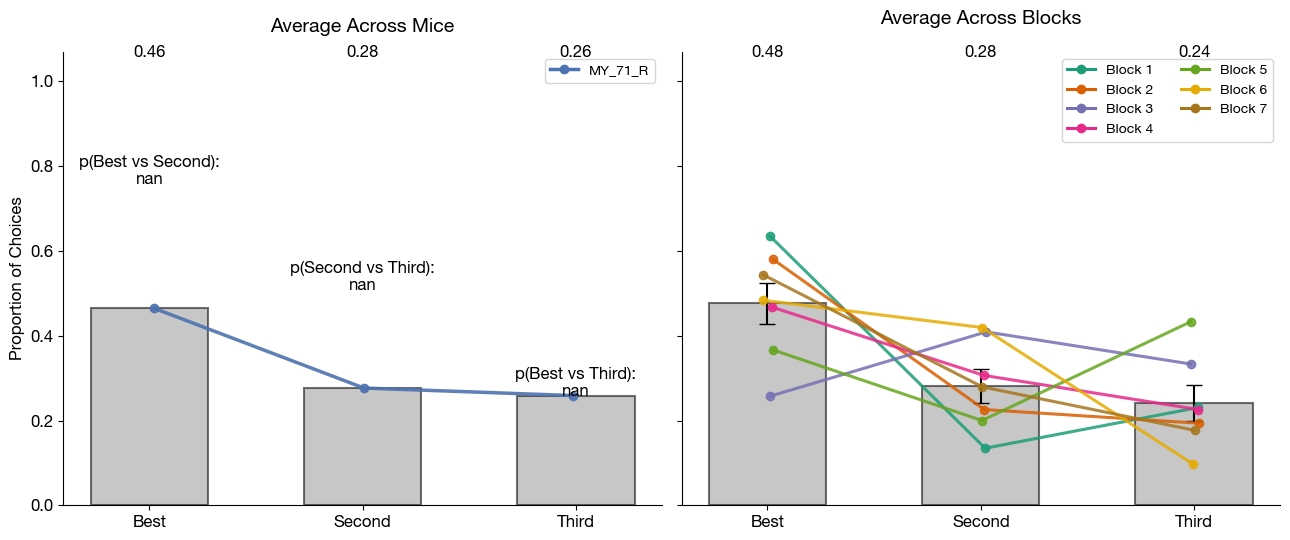


imaging signature 2 believed ranks: 1 subjects, 3 imaging sessions
Believed-rank reversal windows: 8; valid windows: 8
Plotting believed rank proportions for imaging signature 2


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


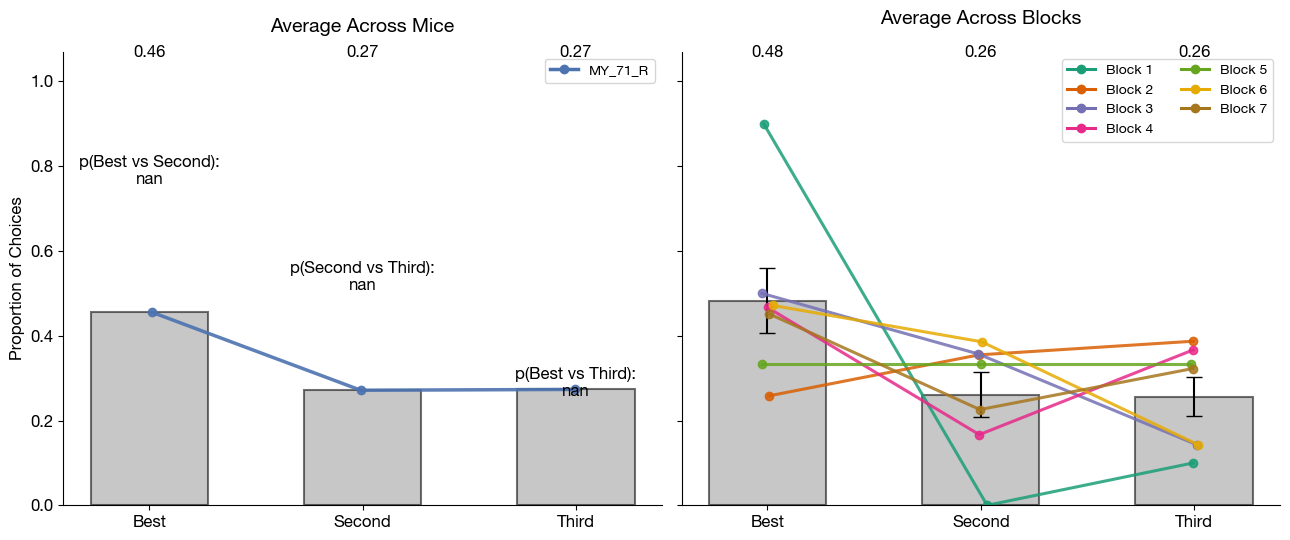


imaging signature 3 believed ranks: 1 subjects, 3 imaging sessions
Believed-rank reversal windows: 7; valid windows: 7
Plotting believed rank proportions for imaging signature 3


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


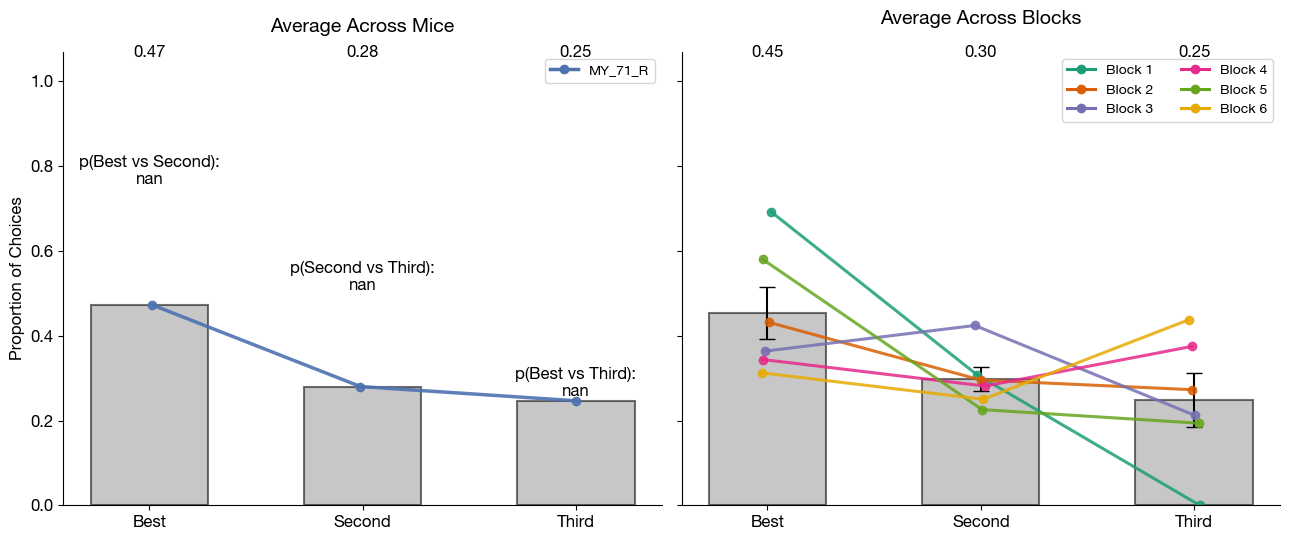


imaging signature 4 believed ranks: 1 subjects, 3 imaging sessions
Believed-rank reversal windows: 8; valid windows: 8
Plotting believed rank proportions for imaging signature 4


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


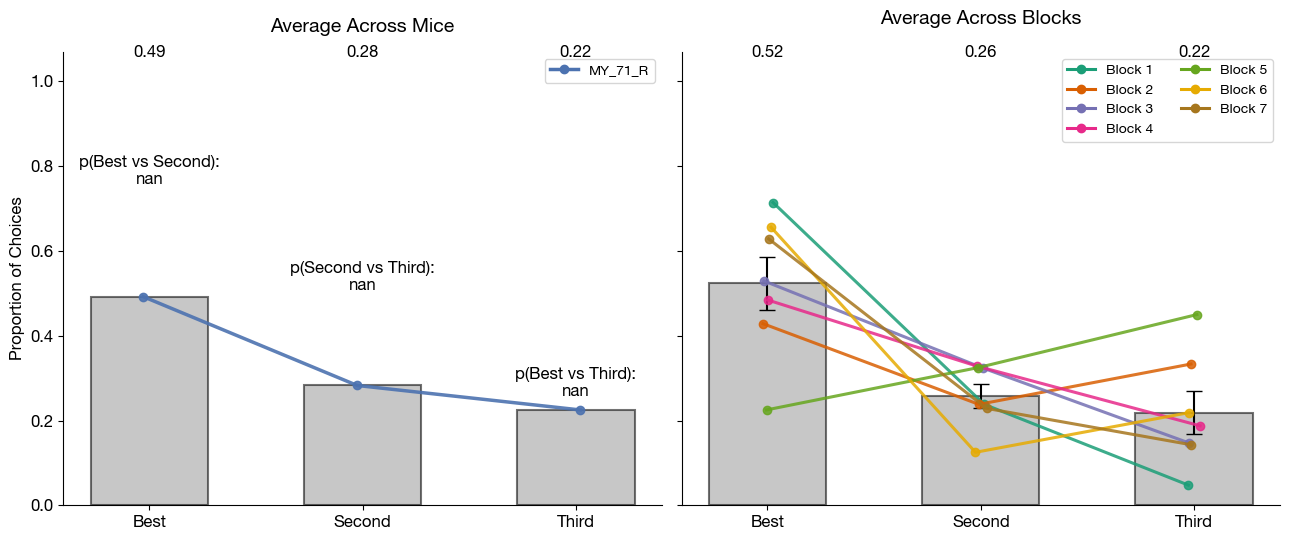


imaging signature 5 believed ranks: 1 subjects, 3 imaging sessions
Believed-rank reversal windows: 6; valid windows: 6
Plotting believed rank proportions for imaging signature 5


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


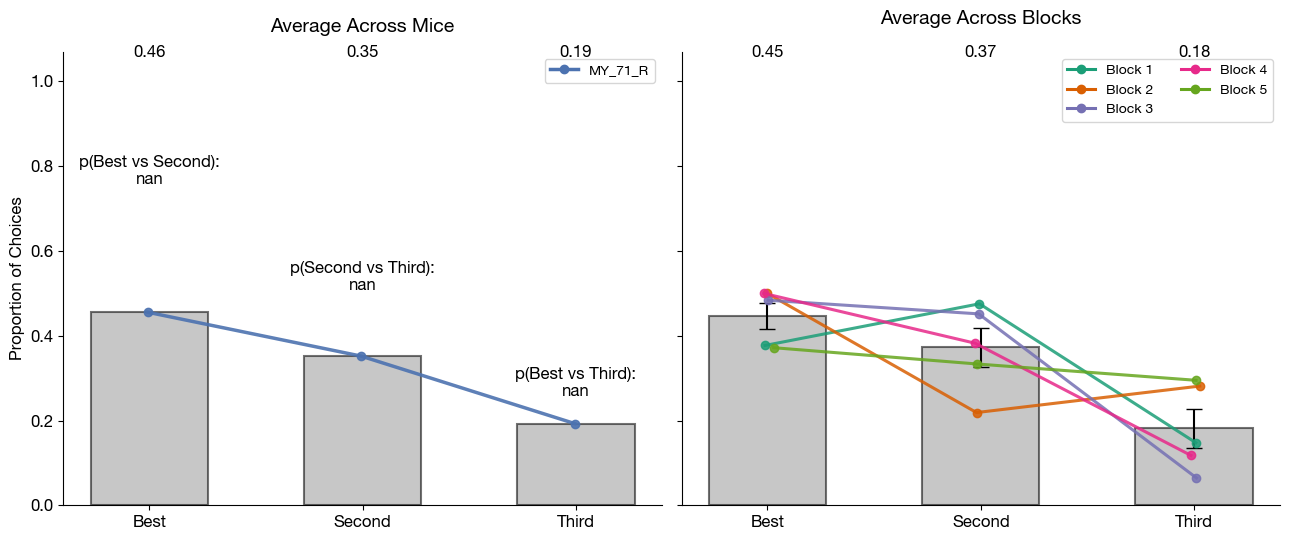

In [144]:
def compute_believed_ranks_continuous(choices, reward_magnitudes):
    """Match the value-analysis notebook's believed-rank calculation.

    Believed values are last-seen magnitudes carried continuously across the
    merged session stream. A trial is valid only after all available arms have
    been seen. Tied believed best/second values are flagged for downstream
    0.5/0.5 splitting.
    """
    last_seen = {}
    results = []

    for i, rm in enumerate(reward_magnitudes):
        choice = choices[i]
        all_arms = list(rm.keys())
        believed = {arm: last_seen[arm] for arm in all_arms if arm in last_seen}

        if len(believed) < len(all_arms):
            results.append(None)
        else:
            ranked = sorted(believed.items(), key=lambda x: (-x[1], str(x[0])))
            best_mag = ranked[0][1] if len(ranked) >= 1 else None
            second_mag = ranked[1][1] if len(ranked) >= 2 else None
            tied = (
                best_mag is not None
                and second_mag is not None
                and best_mag == second_mag
            )
            chosen_rank = None
            for rank_idx, (arm, _) in enumerate(ranked):
                if arm == choice:
                    chosen_rank = ["best", "second", "third"][min(rank_idx, 2)]
                    break
            results.append({"chosen_rank": chosen_rank, "tied": tied})

        if choice and choice in rm:
            last_seen[choice] = rm[choice]

    return results


def get_believed_rank_counts_by_good_reversal(good_reversal_info, subjects_trials):
    """Count believed-rank choices using the value-analysis notebook method."""
    from src.behavior_analysis.get_variables_across_sessions import get_vars_across_all_sessions

    merged, _ = get_vars_across_all_sessions(subjects_trials)
    result = {}

    for subj, reversals in good_reversal_info.items():
        result[subj] = []
        d = merged.get(subj, {})
        reward_by_tower = d.get("reward_magnitudes_by_tower", {}) or {}
        choices_by_tower = d.get("choices_by_tower", {}) or {}
        towers = list(reward_by_tower.keys())

        if not towers:
            continue

        n = max((len(v) for v in reward_by_tower.values()), default=0)
        reward_magnitudes = [
            {tower: reward_by_tower[tower][i] for tower in towers}
            for i in range(n)
        ]

        choices = [None] * n
        for tower, arr in choices_by_tower.items():
            for i, value in enumerate(arr):
                if value == 1 and i < n:
                    choices[i] = tower

        believed = compute_believed_ranks_continuous(choices, reward_magnitudes)

        for reversal in reversals:
            post_idx = reversal.get("trial_window_idx", {}).get("post", [])
            num_best = 0.0
            num_second = 0.0
            num_third = 0.0
            total = 0

            for i in post_idx:
                if i >= len(believed) or believed[i] is None:
                    continue
                trial_belief = believed[i]
                total += 1
                if trial_belief["tied"]:
                    if trial_belief["chosen_rank"] in ("best", "second"):
                        num_best += 0.5
                        num_second += 0.5
                    else:
                        num_third += 1.0
                else:
                    if trial_belief["chosen_rank"] == "best":
                        num_best += 1.0
                    elif trial_belief["chosen_rank"] == "second":
                        num_second += 1.0
                    elif trial_belief["chosen_rank"] == "third":
                        num_third += 1.0

            result[subj].append({
                "best": num_best,
                "second": num_second,
                "third": num_third,
                "total": total,
                "best_prop": num_best / total if total > 0 else float("nan"),
                "second_prop": num_second / total if total > 0 else float("nan"),
                "third_prop": num_third / total if total > 0 else float("nan"),
            })

    return result


if not imaging_signature_trial_groups:
    print("No imaging-signature trial groups found. Run the cells above and confirm included imaging sessions exist.")
else:
    believed_rank_results_by_imaging_signature = {}

    for imaging_signature in signature_order:
        subjects_trials = imaging_signature_trial_groups.get(imaging_signature)
        if not subjects_trials:
            continue

        n_sessions = sum(len(sessions) for sessions in subjects_trials.values())
        print(f"\n{imaging_signature} believed ranks: {len(subjects_trials)} subjects, {n_sessions} imaging sessions")

        believed_reversal_windows = get_good_reversal_info(
            subjects_trials,
            pre=RANK_PRE,
            post=RANK_POST,
            include_first_block=RANK_INCLUDE_FIRST_BLOCK,
        )
        believed_rank_counts = get_believed_rank_counts_by_good_reversal(
            believed_reversal_windows,
            subjects_trials,
        )
        n_reversals = sum(len(rows) for rows in believed_rank_counts.values())
        n_valid_reversals = sum(
            1 for rows in believed_rank_counts.values() for row in rows
            if row.get("total", 0) > 0
        )
        print(f"Believed-rank reversal windows: {n_reversals}; valid windows: {n_valid_reversals}")

        if n_valid_reversals == 0:
            print(f"Skipping {imaging_signature}: no usable believed-rank windows.")
            continue

        believed_p_values = pvalue_paired_t_best_vs_second_vs_third(believed_rank_counts)
        believed_rank_results_by_imaging_signature[imaging_signature] = {
            "subjects_trials": subjects_trials,
            "reversal_windows": believed_reversal_windows,
            "rank_counts_by_good_reversal": believed_rank_counts,
            "p_values": believed_p_values,
        }

        print(f"Plotting believed rank proportions for {imaging_signature}")
        plot_rank_proportions(
            believed_rank_counts,
            average_across_mice_pvalues=believed_p_values,
            save_path=None,
            by_mouse=RANK_PLOT_BY_MOUSE,
            by_block=RANK_PLOT_BY_BLOCK,
            average=RANK_PLOT_AVERAGE,
        )


## Rank Proportions For Most Recent Imaging Problems

Set `NUM_MOST_RECENT_IMAGING_PROBLEMS` to choose the latest mouse-relative imaging problems that all mice have reached. For example, if both mice have reached imaging problem 6 and this is set to `2`, the combined rank-proportions plot uses imaging problems 5 and 6.

Selected most recent common imaging problems: 4, 5


,subject_key,imaging_signature_number,imaging_signature,problem_signature
3,sub-03_id-MY_71_R,4,imaging signature 4,init=B2; choices=A2+B1+C3
4,sub-03_id-MY_71_R,5,imaging signature 5,init=B2; choices=B1+B3+C2



imaging signature 4: 1 subjects, 3 imaging sessions
Rank-proportion windows: 8

imaging signature 5: 1 subjects, 3 imaging sessions
Rank-proportion windows: 6


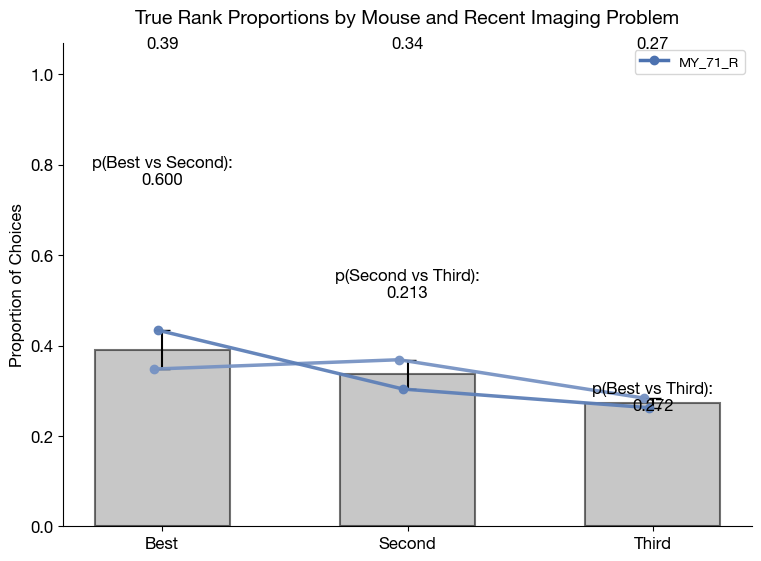

In [145]:
NUM_MOST_RECENT_IMAGING_PROBLEMS = 2


def clean_subject_label(subject_key):
    return str(subject_key).split("_id-")[-1]


def get_common_recent_imaging_signature_numbers(session_summary, n_recent):
    if session_summary.empty:
        return []

    per_subject_numbers = []
    for _, subject_table in session_summary.groupby("subject_id", sort=True):
        nums = set(subject_table["imaging_signature_number"].dropna().astype(int).unique())
        if nums:
            per_subject_numbers.append(nums)

    if not per_subject_numbers:
        return []

    common_numbers = sorted(set.intersection(*per_subject_numbers))
    return common_numbers[-n_recent:]


selected_signature_numbers = get_common_recent_imaging_signature_numbers(
    session_summary,
    NUM_MOST_RECENT_IMAGING_PROBLEMS,
)
selected_signatures = [f"imaging signature {n}" for n in selected_signature_numbers]

if not selected_signatures:
    print("No common imaging signatures found across mice.")
else:
    print(
        f"Selected most recent common imaging problems: "
        f"{', '.join(str(n) for n in selected_signature_numbers)}"
    )
    display(
        signature_lookup[
            signature_lookup["imaging_signature_number"].isin(selected_signature_numbers)
        ].sort_values(["subject_key", "imaging_signature_number"])
    )

    if "imaging_signature_trial_groups" not in globals():
        imaging_signature_trial_groups = build_imaging_signature_trial_groups(
            subjects_trials_by_problem,
            signature_summary,
        )

    most_recent_rank_results_by_imaging_signature = {}
    combined_recent_rank_counts_by_good_reversal = {}

    for imaging_signature_number, imaging_signature in zip(selected_signature_numbers, selected_signatures):
        subjects_trials = imaging_signature_trial_groups.get(imaging_signature)
        if not subjects_trials:
            print(f"Skipping {imaging_signature}: no included imaging sessions found.")
            continue

        n_sessions = sum(len(sessions) for sessions in subjects_trials.values())
        print(f"\n{imaging_signature}: {len(subjects_trials)} subjects, {n_sessions} imaging sessions")

        reversal_windows = get_good_reversal_info(
            subjects_trials,
            pre=RANK_PRE,
            post=RANK_POST,
            include_first_block=RANK_INCLUDE_FIRST_BLOCK,
        )
        rank_counts_by_good_reversal = get_rank_counts_by_good_reversal(reversal_windows)
        n_reversals = sum(len(rows) for rows in rank_counts_by_good_reversal.values())
        print(f"Rank-proportion windows: {n_reversals}")

        if n_reversals == 0:
            print(f"Skipping {imaging_signature}: no usable reversal windows.")
            continue

        most_recent_rank_results_by_imaging_signature[imaging_signature] = {
            "subjects_trials": subjects_trials,
            "reversal_windows": reversal_windows,
            "rank_counts_by_good_reversal": rank_counts_by_good_reversal,
        }

        for subject_key, rows in rank_counts_by_good_reversal.items():
            clean_mouse = clean_subject_label(subject_key)
            combined_key = f"{clean_mouse} imaging problem {imaging_signature_number}"
            combined_recent_rank_counts_by_good_reversal[combined_key] = rows

    if not combined_recent_rank_counts_by_good_reversal:
        print("No usable rank-proportion windows found for the selected recent imaging problems.")
    else:
        recent_p_values = pvalue_paired_t_best_vs_second_vs_third(
            combined_recent_rank_counts_by_good_reversal
        )
        plot_rank_proportions_mouse_problem_breakdown(
            combined_recent_rank_counts_by_good_reversal,
            title="True Rank Proportions by Mouse and Recent Imaging Problem",
            p_values=recent_p_values,
        )


## Believed Rank Proportions For Most Recent Imaging Problems

This repeats the configurable most-recent-problems plot using believed ranks instead of true ranks.


imaging signature 4 believed ranks: 1 subjects, 3 imaging sessions
Believed-rank reversal windows: 8; valid windows: 8

imaging signature 5 believed ranks: 1 subjects, 3 imaging sessions
Believed-rank reversal windows: 6; valid windows: 6


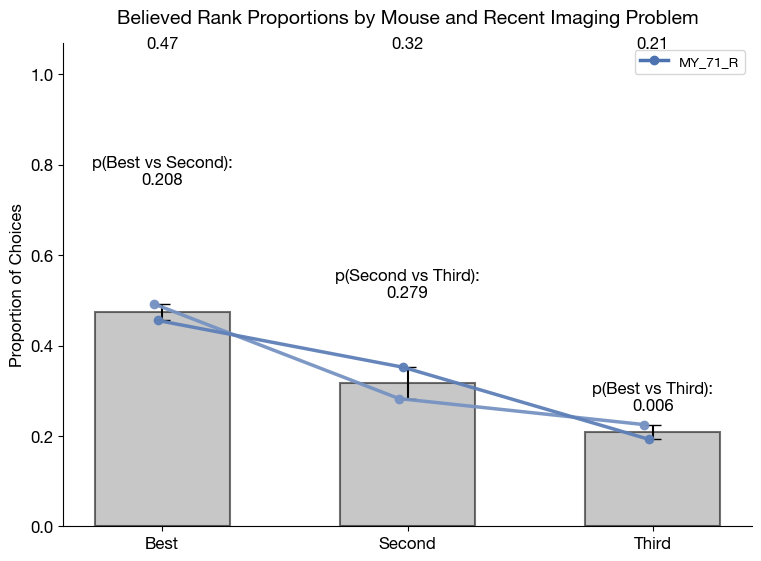

In [146]:
if not selected_signatures:
    print("No common imaging signatures found across mice.")
else:
    if "imaging_signature_trial_groups" not in globals():
        imaging_signature_trial_groups = build_imaging_signature_trial_groups(
            subjects_trials_by_problem,
            signature_summary,
        )

    most_recent_believed_rank_results_by_imaging_signature = {}
    combined_recent_believed_rank_counts = {}

    for imaging_signature_number, imaging_signature in zip(selected_signature_numbers, selected_signatures):
        subjects_trials = imaging_signature_trial_groups.get(imaging_signature)
        if not subjects_trials:
            print(f"Skipping {imaging_signature}: no included imaging sessions found.")
            continue

        n_sessions = sum(len(sessions) for sessions in subjects_trials.values())
        print(f"\n{imaging_signature} believed ranks: {len(subjects_trials)} subjects, {n_sessions} imaging sessions")

        believed_reversal_windows = get_good_reversal_info(
            subjects_trials,
            pre=RANK_PRE,
            post=RANK_POST,
            include_first_block=RANK_INCLUDE_FIRST_BLOCK,
        )
        believed_rank_counts = get_believed_rank_counts_by_good_reversal(
            believed_reversal_windows,
            subjects_trials,
        )
        n_reversals = sum(len(rows) for rows in believed_rank_counts.values())
        n_valid_reversals = sum(
            1 for rows in believed_rank_counts.values() for row in rows
            if row.get("total", 0) > 0
        )
        print(f"Believed-rank reversal windows: {n_reversals}; valid windows: {n_valid_reversals}")

        if n_valid_reversals == 0:
            print(f"Skipping {imaging_signature}: no usable believed-rank windows.")
            continue

        most_recent_believed_rank_results_by_imaging_signature[imaging_signature] = {
            "subjects_trials": subjects_trials,
            "reversal_windows": believed_reversal_windows,
            "rank_counts_by_good_reversal": believed_rank_counts,
        }

        for subject_key, rows in believed_rank_counts.items():
            clean_mouse = clean_subject_label(subject_key)
            combined_key = f"{clean_mouse} imaging problem {imaging_signature_number} believed"
            combined_recent_believed_rank_counts[combined_key] = rows

    if not combined_recent_believed_rank_counts:
        print("No usable believed-rank windows found for the selected recent imaging problems.")
    else:
        recent_believed_p_values = pvalue_paired_t_best_vs_second_vs_third(
            combined_recent_believed_rank_counts
        )
        plot_rank_proportions_mouse_problem_breakdown(
            combined_recent_believed_rank_counts,
            title="Believed Rank Proportions by Mouse and Recent Imaging Problem",
            p_values=recent_believed_p_values,
        )

## Rank Proportions For All But Last Imaging Problem

Selected common imaging problems, excluding the last: 1, 2, 3, 4


,subject_key,imaging_signature_number,imaging_signature,problem_signature
0,sub-03_id-MY_71_R,1,imaging signature 1,init=B2; choices=A1+C1+C3
1,sub-03_id-MY_71_R,2,imaging signature 2,init=B2; choices=A2+B1+C2
2,sub-03_id-MY_71_R,3,imaging signature 3,init=B2; choices=A1+B3+C1
3,sub-03_id-MY_71_R,4,imaging signature 4,init=B2; choices=A2+B1+C3



imaging signature 1: 1 subjects, 4 imaging sessions
Rank-proportion windows: 8

imaging signature 2: 1 subjects, 3 imaging sessions
Rank-proportion windows: 8

imaging signature 3: 1 subjects, 3 imaging sessions
Rank-proportion windows: 7

imaging signature 4: 1 subjects, 3 imaging sessions
Rank-proportion windows: 8


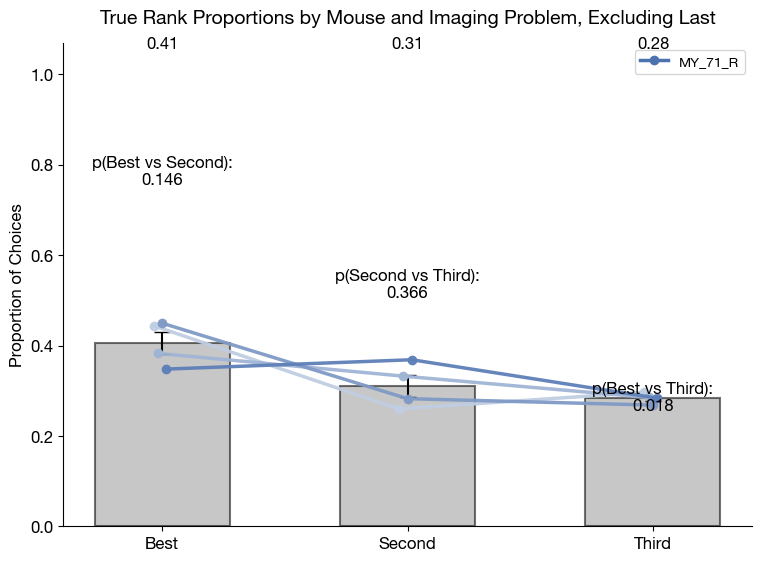

In [147]:
def get_common_all_but_last_imaging_signature_numbers(session_summary):
    if session_summary.empty:
        return []

    per_subject_numbers = []
    for _, subject_table in session_summary.groupby("subject_id", sort=True):
        nums = set(subject_table["imaging_signature_number"].dropna().astype(int).unique())
        if nums:
            per_subject_numbers.append(nums)

    if not per_subject_numbers:
        return []

    common_numbers = sorted(set.intersection(*per_subject_numbers))
    return common_numbers[:-1]


all_but_last_signature_numbers = get_common_all_but_last_imaging_signature_numbers(session_summary)
all_but_last_signatures = [f"imaging signature {n}" for n in all_but_last_signature_numbers]

if not all_but_last_signatures:
    print("No common imaging signatures found after excluding the last imaging problem.")
else:
    print(
        f"Selected common imaging problems, excluding the last: "
        f"{', '.join(str(n) for n in all_but_last_signature_numbers)}"
    )
    display(
        signature_lookup[
            signature_lookup["imaging_signature_number"].isin(all_but_last_signature_numbers)
        ].sort_values(["subject_key", "imaging_signature_number"])
    )

    if "imaging_signature_trial_groups" not in globals():
        imaging_signature_trial_groups = build_imaging_signature_trial_groups(
            subjects_trials_by_problem,
            signature_summary,
        )

    all_but_last_rank_results_by_imaging_signature = {}
    combined_all_but_last_rank_counts = {}

    for imaging_signature_number, imaging_signature in zip(all_but_last_signature_numbers, all_but_last_signatures):
        subjects_trials = imaging_signature_trial_groups.get(imaging_signature)
        if not subjects_trials:
            print(f"Skipping {imaging_signature}: no included imaging sessions found.")
            continue

        n_sessions = sum(len(sessions) for sessions in subjects_trials.values())
        print(f"\n{imaging_signature}: {len(subjects_trials)} subjects, {n_sessions} imaging sessions")

        reversal_windows = get_good_reversal_info(
            subjects_trials,
            pre=RANK_PRE,
            post=RANK_POST,
            include_first_block=RANK_INCLUDE_FIRST_BLOCK,
        )
        rank_counts_by_good_reversal = get_rank_counts_by_good_reversal(reversal_windows)
        n_reversals = sum(len(rows) for rows in rank_counts_by_good_reversal.values())
        print(f"Rank-proportion windows: {n_reversals}")

        if n_reversals == 0:
            print(f"Skipping {imaging_signature}: no usable reversal windows.")
            continue

        all_but_last_rank_results_by_imaging_signature[imaging_signature] = {
            "subjects_trials": subjects_trials,
            "reversal_windows": reversal_windows,
            "rank_counts_by_good_reversal": rank_counts_by_good_reversal,
        }

        for subject_key, rows in rank_counts_by_good_reversal.items():
            clean_mouse = clean_subject_label(subject_key)
            combined_key = f"{clean_mouse} imaging problem {imaging_signature_number}"
            combined_all_but_last_rank_counts[combined_key] = rows

    if not combined_all_but_last_rank_counts:
        print("No usable true-rank windows found after excluding the last imaging problem.")
    else:
        all_but_last_p_values = pvalue_paired_t_best_vs_second_vs_third(
            combined_all_but_last_rank_counts
        )
        plot_rank_proportions_mouse_problem_breakdown(
            combined_all_but_last_rank_counts,
            title="True Rank Proportions by Mouse and Imaging Problem, Excluding Last",
            p_values=all_but_last_p_values,
        )


## Believed Rank Proportions For All But Last Imaging Problem


imaging signature 1 believed ranks: 1 subjects, 4 imaging sessions
Believed-rank reversal windows: 8; valid windows: 8

imaging signature 2 believed ranks: 1 subjects, 3 imaging sessions
Believed-rank reversal windows: 8; valid windows: 8

imaging signature 3 believed ranks: 1 subjects, 3 imaging sessions
Believed-rank reversal windows: 7; valid windows: 7

imaging signature 4 believed ranks: 1 subjects, 3 imaging sessions
Believed-rank reversal windows: 8; valid windows: 8


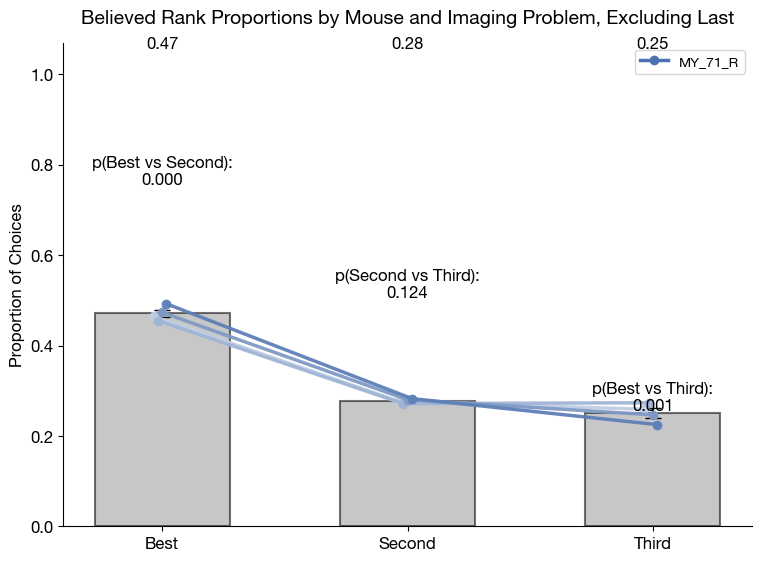

In [148]:
if not all_but_last_signatures:
    print("No common imaging signatures found after excluding the last imaging problem.")
else:
    if "imaging_signature_trial_groups" not in globals():
        imaging_signature_trial_groups = build_imaging_signature_trial_groups(
            subjects_trials_by_problem,
            signature_summary,
        )

    all_but_last_believed_rank_results_by_imaging_signature = {}
    combined_all_but_last_believed_rank_counts = {}

    for imaging_signature_number, imaging_signature in zip(all_but_last_signature_numbers, all_but_last_signatures):
        subjects_trials = imaging_signature_trial_groups.get(imaging_signature)
        if not subjects_trials:
            print(f"Skipping {imaging_signature}: no included imaging sessions found.")
            continue

        n_sessions = sum(len(sessions) for sessions in subjects_trials.values())
        print(f"\n{imaging_signature} believed ranks: {len(subjects_trials)} subjects, {n_sessions} imaging sessions")

        believed_reversal_windows = get_good_reversal_info(
            subjects_trials,
            pre=RANK_PRE,
            post=RANK_POST,
            include_first_block=RANK_INCLUDE_FIRST_BLOCK,
        )
        believed_rank_counts = get_believed_rank_counts_by_good_reversal(
            believed_reversal_windows,
            subjects_trials,
        )
        n_reversals = sum(len(rows) for rows in believed_rank_counts.values())
        n_valid_reversals = sum(
            1 for rows in believed_rank_counts.values() for row in rows
            if row.get("total", 0) > 0
        )
        print(f"Believed-rank reversal windows: {n_reversals}; valid windows: {n_valid_reversals}")

        if n_valid_reversals == 0:
            print(f"Skipping {imaging_signature}: no usable believed-rank windows.")
            continue

        all_but_last_believed_rank_results_by_imaging_signature[imaging_signature] = {
            "subjects_trials": subjects_trials,
            "reversal_windows": believed_reversal_windows,
            "rank_counts_by_good_reversal": believed_rank_counts,
        }

        for subject_key, rows in believed_rank_counts.items():
            clean_mouse = clean_subject_label(subject_key)
            combined_key = f"{clean_mouse} imaging problem {imaging_signature_number} believed"
            combined_all_but_last_believed_rank_counts[combined_key] = rows

    if not combined_all_but_last_believed_rank_counts:
        print("No usable believed-rank windows found after excluding the last imaging problem.")
    else:
        all_but_last_believed_p_values = pvalue_paired_t_best_vs_second_vs_third(
            combined_all_but_last_believed_rank_counts
        )
        plot_rank_proportions_mouse_problem_breakdown(
            combined_all_but_last_believed_rank_counts,
            title="Believed Rank Proportions by Mouse and Imaging Problem, Excluding Last",
            p_values=all_but_last_believed_p_values,
        )


## True Rank Proportions Averaged Across All Imaging Problems By Mouse

This collapses all true-rank windows across imaging problems within each mouse first, then runs `plot_rank_proportions` on the mouse-level groups.

,subject,n_rank_windows,n_post_trials
0,MY_71_R,37,1223


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero


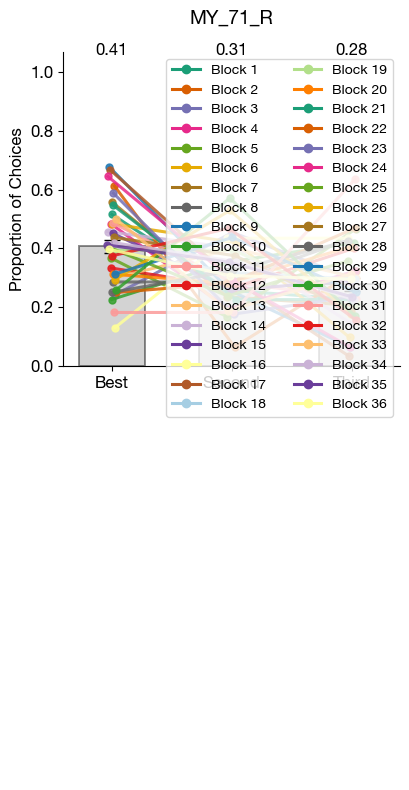

/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


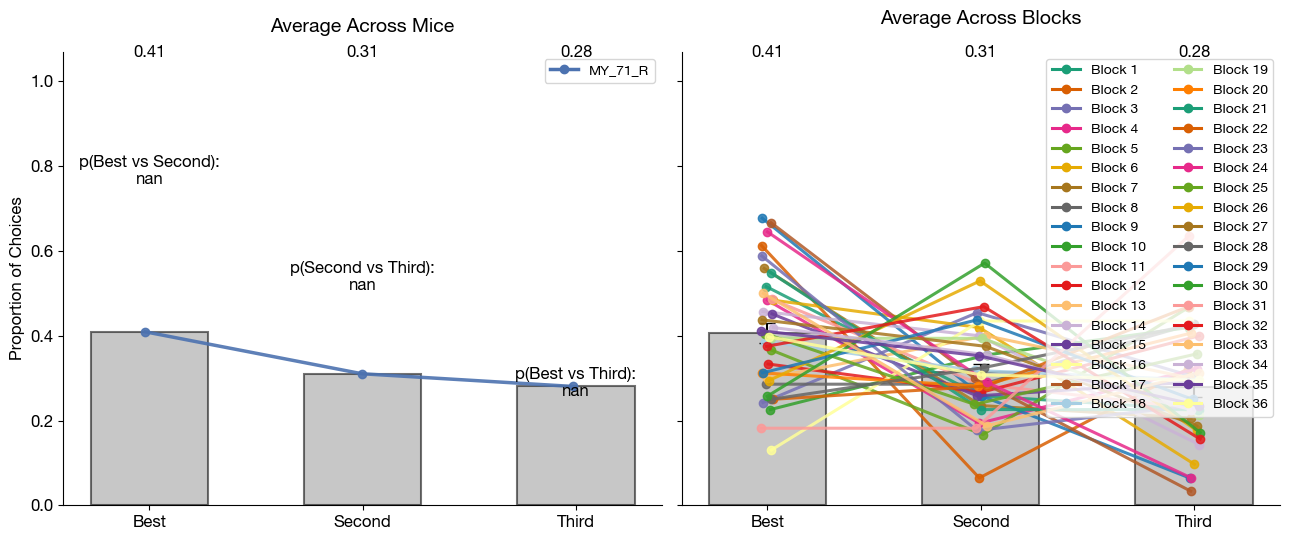

In [149]:
# ----------------------------
# True-rank plot averaged across all imaging problems within each mouse
# ----------------------------
if "rank_results_by_imaging_signature" not in globals():
    print("Run the 'Rank Proportions By Imaging Signature' cell first.")
elif not rank_results_by_imaging_signature:
    print("No true-rank results found to combine.")
else:
    restore_mouse_palette()
    rank_counts_by_mouse_all_problems = {}

    for _, result in rank_results_by_imaging_signature.items():
        for subject_key, rows in result["rank_counts_by_good_reversal"].items():
            clean_mouse = str(subject_key).split("_id-")[-1]
            rank_counts_by_mouse_all_problems.setdefault(clean_mouse, []).extend(rows)

    if not rank_counts_by_mouse_all_problems:
        print("No usable true-rank windows found across all imaging problems.")
    else:
        display(pd.DataFrame([
            {
                "subject": subject,
                "n_rank_windows": len(rows),
                "n_post_trials": sum(r.get("total", 0) for r in rows),
            }
            for subject, rows in rank_counts_by_mouse_all_problems.items()
        ]))

        all_problem_mouse_p_values = pvalue_paired_t_best_vs_second_vs_third(
            rank_counts_by_mouse_all_problems
        )

        plot_rank_proportions(
            rank_counts_by_mouse_all_problems,
            average_across_mice_pvalues=all_problem_mouse_p_values,
            save_path=None,
            by_mouse=True,
            by_block=False,
            average=True,
        )

## True Rank Proportions Broken Down By Imaging Problem

This keeps each mouse/problem combination separate in one true-rank `plot_rank_proportions` plot, so the lines show the problem-level breakdown.

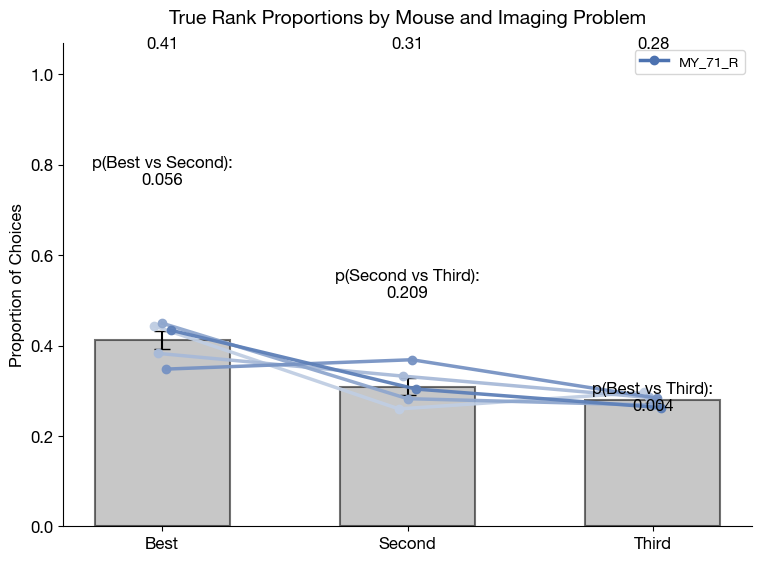

In [150]:
# ----------------------------
# True-rank plot broken down by imaging problem
# ----------------------------
if "rank_results_by_imaging_signature" not in globals():
    print("Run the 'Rank Proportions By Imaging Signature' cell first.")
elif not rank_results_by_imaging_signature:
    print("No true-rank results found to combine.")
else:
    problem_labels = {
        sig: f"Problem {i + 1}"
        for i, sig in enumerate(signature_order)
    }

    combined_rank_counts_by_good_reversal = {}

    for imaging_signature, result in rank_results_by_imaging_signature.items():
        problem_label = problem_labels[imaging_signature]

        for reversal_key, rows in result["rank_counts_by_good_reversal"].items():
            clean_mouse = str(reversal_key).split("_id-")[-1]
            combined_key = f"{clean_mouse} {problem_label}"
            combined_rank_counts_by_good_reversal[combined_key] = rows

    if not combined_rank_counts_by_good_reversal:
        print("No usable true-rank windows found across all imaging problems.")
    else:
        combined_p_values = pvalue_paired_t_best_vs_second_vs_third(
            combined_rank_counts_by_good_reversal
        )
        plot_rank_proportions_mouse_problem_breakdown(
            combined_rank_counts_by_good_reversal,
            title="True Rank Proportions by Mouse and Imaging Problem",
            p_values=combined_p_values,
        )

## Believed Rank Proportions Averaged Across All Imaging Problems By Mouse

This collapses all believed-rank windows across imaging problems within each mouse first, then runs `plot_rank_proportions` on the mouse-level groups.

,subject,n_rank_windows,n_post_trials
0,MY_71_R,37,1180


/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: divide by zero encountered in divide
  var *= (n / (n-ddof))  # to avoid error on division by zero
/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/scipy/stats/_stats_py.py:1251: RuntimeWarning: invalid value encountered in scalar multiply
  var *= (n / (n-ddof))  # to avoid error on division by zero


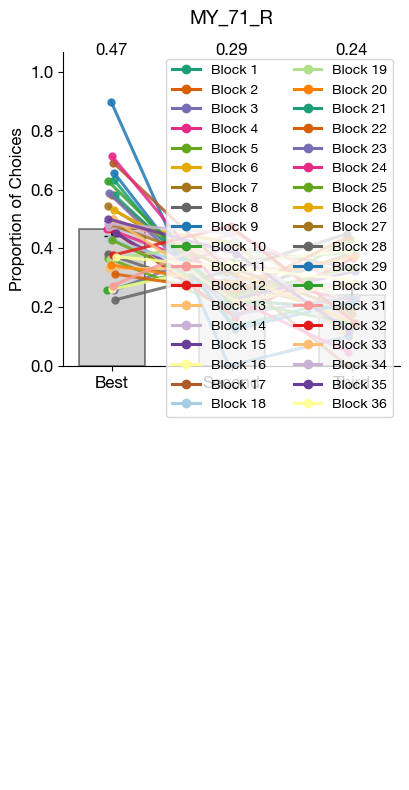

/Users/megyoung/anaconda3/envs/magnitude-bandit-analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


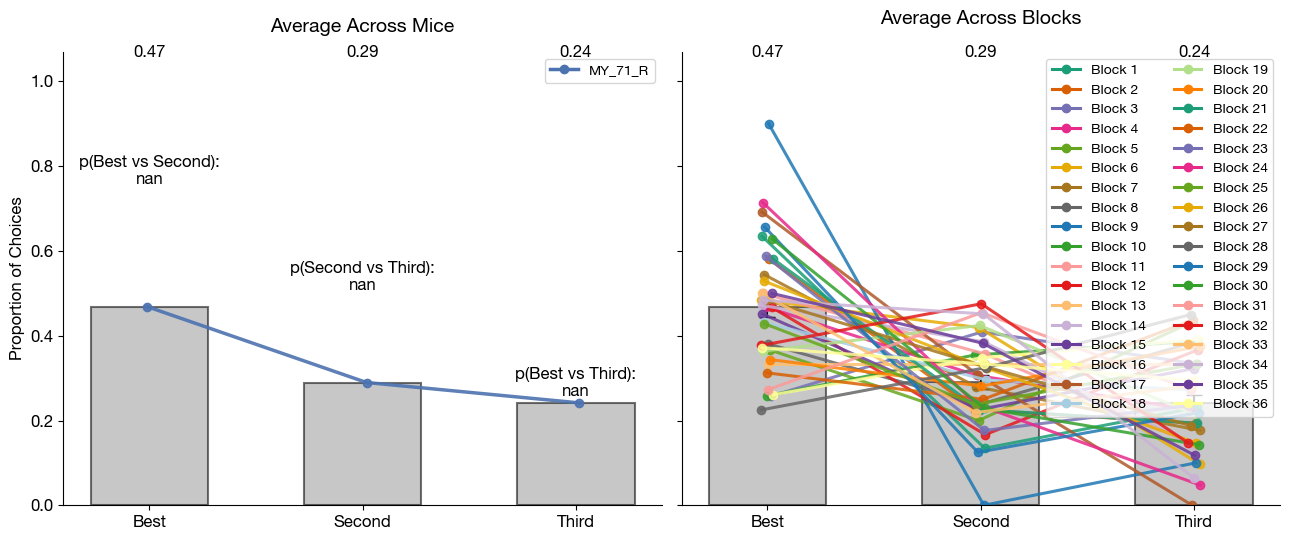

In [151]:
# ----------------------------
# Believed-rank plot averaged across all imaging problems within each mouse
# ----------------------------
if "believed_rank_results_by_imaging_signature" not in globals():
    print("Run the 'Believed Rank Proportions By Imaging Signature' cell first.")
elif not believed_rank_results_by_imaging_signature:
    print("No believed-rank results found to combine.")
else:
    restore_mouse_palette()
    believed_rank_counts_by_mouse_all_problems = {}

    for _, result in believed_rank_results_by_imaging_signature.items():
        for subject_key, rows in result["rank_counts_by_good_reversal"].items():
            clean_mouse = str(subject_key).split("_id-")[-1]
            believed_rank_counts_by_mouse_all_problems.setdefault(clean_mouse, []).extend(rows)

    if not believed_rank_counts_by_mouse_all_problems:
        print("No usable believed-rank windows found across all imaging problems.")
    else:
        display(pd.DataFrame([
            {
                "subject": subject,
                "n_rank_windows": len(rows),
                "n_post_trials": sum(r.get("total", 0) for r in rows),
            }
            for subject, rows in believed_rank_counts_by_mouse_all_problems.items()
        ]))

        believed_all_problem_mouse_p_values = pvalue_paired_t_best_vs_second_vs_third(
            believed_rank_counts_by_mouse_all_problems
        )

        plot_rank_proportions(
            believed_rank_counts_by_mouse_all_problems,
            average_across_mice_pvalues=believed_all_problem_mouse_p_values,
            save_path=None,
            by_mouse=True,
            by_block=False,
            average=True,
        )

## Believed Rank Proportions Broken Down By Imaging Problem

This keeps each mouse/problem combination separate in one believed-rank `plot_rank_proportions` plot, so the lines show the problem-level breakdown.

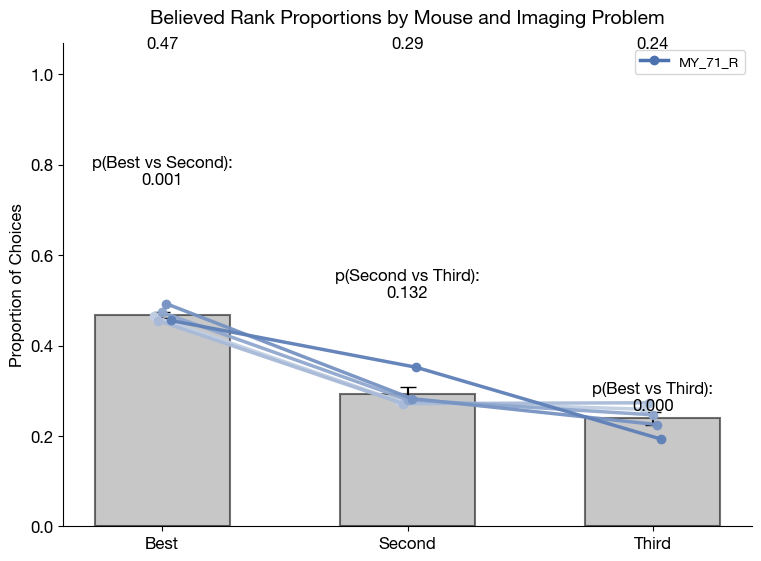

In [152]:
# ----------------------------
# Believed-rank plot broken down by imaging problem
# ----------------------------
if "believed_rank_results_by_imaging_signature" not in globals():
    print("Run the 'Believed Rank Proportions By Imaging Signature' cell first.")
elif not believed_rank_results_by_imaging_signature:
    print("No believed-rank results found to combine.")
else:
    problem_labels = {
        sig: f"Imaging Problem {i + 1}"
        for i, sig in enumerate(signature_order)
    }

    combined_believed_rank_counts_by_good_reversal = {}

    for imaging_signature, result in believed_rank_results_by_imaging_signature.items():
        problem_label = problem_labels[imaging_signature]

        for reversal_key, rows in result["rank_counts_by_good_reversal"].items():
            clean_mouse = str(reversal_key).split("_id-")[-1]
            combined_key = f"{clean_mouse} {problem_label}"
            combined_believed_rank_counts_by_good_reversal[combined_key] = rows

    if not combined_believed_rank_counts_by_good_reversal:
        print("No usable believed-rank windows found across all imaging problems.")
    else:
        combined_believed_p_values = pvalue_paired_t_best_vs_second_vs_third(
            combined_believed_rank_counts_by_good_reversal
        )
        plot_rank_proportions_mouse_problem_breakdown(
            combined_believed_rank_counts_by_good_reversal,
            title="Believed Rank Proportions by Mouse and Imaging Problem",
            p_values=combined_believed_p_values,
        )

In [153]:
example = next(iter(rank_results_by_imaging_signature.values()))
example["rank_counts_by_good_reversal"]
first_key = next(iter(example["rank_counts_by_good_reversal"]))
first_key = next(iter(example["rank_counts_by_good_reversal"]))

print(type(example["rank_counts_by_good_reversal"][first_key]))
print(len(example["rank_counts_by_good_reversal"][first_key]))
print(example["rank_counts_by_good_reversal"][first_key][0])

<class 'list'>
8
{'best': 16, 'second': 8, 'third': 7, 'total': 31, 'best_prop': 0.5161290322580645, 'second_prop': 0.25806451612903225, 'third_prop': 0.22580645161290322}
